
**PROYECTO**

**MODELO 1 - SIN NORMALIZAR**

In [1]:
import pandas as pd


def cargar_dataset(ruta_archivo):
    """
    Carga el dataset desde un archivo CSV.

    Parámetros:
    ruta_archivo (str): Ruta completa del archivo CSV.

    Retorna:
    DataFrame: Dataset cargado en un DataFrame de pandas.
    """
    try:
        df = pd.read_csv(ruta_archivo, sep=";")
        return df
    except FileNotFoundError:
        raise FileNotFoundError("No se encontró el archivo en la ruta especificada.")
    except Exception as e:
        raise Exception(f"Error al cargar el dataset: {e}")


# Ruta del archivo
ruta = r"C:\Users\PERSONAL\Desktop\PROYECTO FINAL METODOS NUMERICOS\train.csv"

# Cargar datos
df = cargar_dataset(ruta)

# Visualizar las primeras filas
df.head()


,Id,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea,SalePrice
0,1,8450,7,2003,706,856,856,1710,2,2,548,208500
1,2,9600,6,1976,978,1262,1262,1262,2,2,460,181500
2,3,11250,7,2001,486,920,920,1786,2,2,608,223500
3,4,9550,7,1915,216,756,961,1717,1,3,642,140000
4,5,14260,8,2000,655,1145,1145,2198,2,3,836,250000


In [2]:
def separar_variables(df, columna_objetivo):
    """
    Separa el conjunto de datos en variables independientes (X)
    y variable dependiente (y).

    Parámetros:
    df (DataFrame): Dataset completo.
    columna_objetivo (str): Nombre de la variable objetivo.

    Retorna:
    X (DataFrame): Variables independientes.
    y (Series): Variable dependiente.
    """
    try:
        X = df.drop(columna_objetivo, axis=1)
        y = df[columna_objetivo]
        return X, y
    except KeyError:
        raise KeyError("La columna objetivo no existe en el DataFrame.")
    except Exception as e:
        raise Exception(f"Error al separar variables: {e}")


# Separación de variables
X, y = separar_variables(df, "SalePrice")

# Verificación de resultados
print("Variables independientes (X):")
display(X.head())

print("Variable dependiente (y):")
display(y.head().to_frame())



Variables independientes (X):


,Id,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea
0,1,8450,7,2003,706,856,856,1710,2,2,548
1,2,9600,6,1976,978,1262,1262,1262,2,2,460
2,3,11250,7,2001,486,920,920,1786,2,2,608
3,4,9550,7,1915,216,756,961,1717,1,3,642
4,5,14260,8,2000,655,1145,1145,2198,2,3,836


Variable dependiente (y):


,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000


In [3]:
import numpy as np


def preparar_datos(X, y, columna_id):
    """
    Prepara los datos para el modelo de mínimos cuadrados,
    eliminando columnas no relevantes y convirtiendo a forma matricial.

    Parámetros:
    X (DataFrame): Variables independientes.
    y (Series): Variable dependiente.
    columna_id (str): Nombre de la columna identificadora.

    Retorna:
    matriz_A (ndarray): Matriz de variables independientes.
    vector_b (ndarray): Vector de valores reales.
    """
    try:
        X_modelo = X.drop(columna_id, axis=1)
        matriz_A = X_modelo.values
        vector_b = y.values
        return matriz_A, vector_b
    except KeyError:
        raise KeyError("La columna Id no existe en el conjunto de datos.")
    except Exception as e:
        raise Exception(f"Error al preparar los datos: {e}")


def calcular_minimos_cuadrados(matriz_A, vector_b):
    """
    Calcula los coeficientes del modelo utilizando
    el método de mínimos cuadrados mediante ecuaciones normales.

    Parámetros:
    matriz_A (ndarray): Matriz de variables independientes.
    vector_b (ndarray): Vector de valores reales.

    Retorna:
    ndarray: Vector de coeficientes del modelo.
    """
    try:
        matriz_AT = matriz_A.T
        matriz_ATA = np.dot(matriz_AT, matriz_A)
        vector_ATb = np.dot(matriz_AT, vector_b)
        coeficientes = np.linalg.solve(matriz_ATA, vector_ATb)
        return coeficientes
    except np.linalg.LinAlgError:
        raise ValueError("La matriz AᵀA no es invertible.")
    except Exception as e:
        raise Exception(f"Error en el cálculo de mínimos cuadrados: {e}")


def predecir_precios(matriz_A, coeficientes):
    """
    Calcula los valores estimados del precio de las viviendas.

    Parámetros:
    matriz_A (ndarray): Matriz de variables independientes.
    coeficientes (ndarray): Coeficientes del modelo.

    Retorna:
    ndarray: Valores estimados.
    """
    return np.dot(matriz_A, coeficientes)


# Preparación de datos
matriz_A, vector_b = preparar_datos(X, y, "Id")

# Cálculo del modelo de mínimos cuadrados
coeficientes_modelo = calcular_minimos_cuadrados(matriz_A, vector_b)

# Predicción de precios
precios_estimados = predecir_precios(matriz_A, coeficientes_modelo)


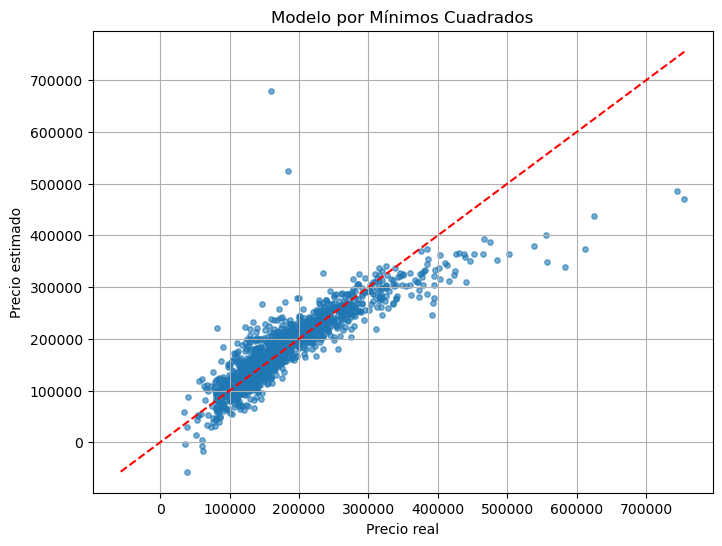

In [4]:
import matplotlib.pyplot as plt


def graficar_predicciones(y_real, y_estimado):
    """
    Grafica la comparación entre los valores reales y los valores
    estimados del modelo de mínimos cuadrados.

    Parámetros:
    y_real (array-like): Valores reales del precio.
    y_estimado (array-like): Valores estimados por el modelo.
    """
    plt.figure(figsize=(8, 6))

    plt.scatter(y_real, y_estimado, alpha=0.6, s=15)

    min_val = min(y_real.min(), y_estimado.min())
    max_val = max(y_real.max(), y_estimado.max())

    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.xlabel("Precio real")
    plt.ylabel("Precio estimado")
    plt.title("Modelo por Mínimos Cuadrados")
    plt.grid(True)
    plt.show()


# Visualización del ajuste del modelo
graficar_predicciones(y, precios_estimados)


Ingrese el ID de la vivienda que desea analizar:  1



Datos de la vivienda seleccionada:


,Id,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea,SalePrice
0,1,8450,7,2003,706,856,856,1710,2,2,548,208500



RESULTADOS DE LA PREDICCIÓN
----------------------------------
Precio real:      $208,500.00
Precio estimado:  $215,750.49
Error absoluto:   $7,250.49
Error porcentual: 3.48%


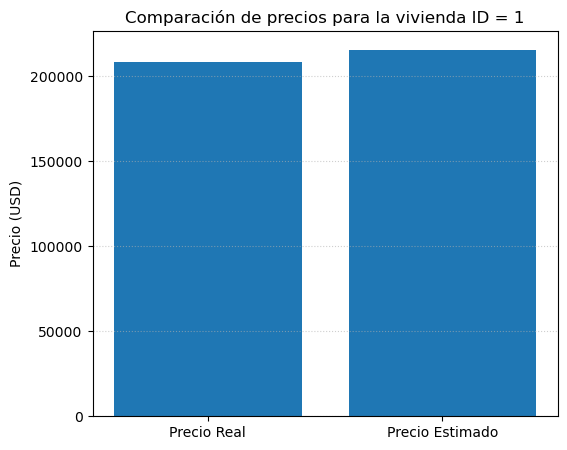

In [5]:
import matplotlib.pyplot as plt


def graficar_comparacion_por_id(id_vivienda, precio_real, precio_estimado):
    """
    Grafica la comparación entre el precio real y el precio estimado
    para una vivienda específica.

    Parámetros:
    id_vivienda (int): ID de la vivienda analizada.
    precio_real (float): Precio real de la vivienda.
    precio_estimado (float): Precio estimado por el modelo.
    """
    valores = [precio_real, precio_estimado]
    etiquetas = ["Precio Real", "Precio Estimado"]

    plt.figure(figsize=(6, 5))
    plt.bar(etiquetas, valores)
    plt.title(f"Comparación de precios para la vivienda ID = {id_vivienda}")
    plt.ylabel("Precio (USD)")
    plt.grid(axis="y", linestyle=":", alpha=0.6)
    plt.show()


def evaluar_vivienda_por_id(df, y, precios_estimados):
    """
    Evalúa una vivienda específica a partir de su ID, mostrando
    el precio real, el precio estimado, los errores y la gráfica comparativa.

    Parámetros:
    df (DataFrame): Dataset completo.
    y (Series): Variable objetivo (precio real).
    precios_estimados (ndarray): Precios estimados por el modelo.
    """
    try:
        id_vivienda = int(input("Ingrese el ID de la vivienda que desea analizar: "))

        fila_casa = df[df["Id"] == id_vivienda]

        if fila_casa.empty:
            print("No se encontró una vivienda con ese ID.")
            return

        print("\nDatos de la vivienda seleccionada:")
        display(fila_casa)

        indice_real = fila_casa.index[0]

        precio_real = y.iloc[indice_real]
        precio_estimado = precios_estimados[indice_real]

        error_absoluto = abs(precio_real - precio_estimado)
        error_porcentual = (error_absoluto / precio_real) * 100

        print("\nRESULTADOS DE LA PREDICCIÓN")
        print("----------------------------------")
        print(f"Precio real:      ${precio_real:,.2f}")
        print(f"Precio estimado:  ${precio_estimado:,.2f}")
        print(f"Error absoluto:   ${error_absoluto:,.2f}")
        print(f"Error porcentual: {error_porcentual:.2f}%")

        # Gráfica comparativa
        graficar_comparacion_por_id(id_vivienda, precio_real, precio_estimado)

    except ValueError:
        print("El ID ingresado no es válido.")
    except Exception as e:
        print(f"Ocurrió un error durante la evaluación: {e}")


# -------------------------
# EJECUCIÓN
# -------------------------
evaluar_vivienda_por_id(df, y, precios_estimados)


In [6]:
def analizar_influencia_variables(X, coeficientes_modelo, columna_id="Id"):
    """
    Analiza la influencia de cada variable en el modelo de mínimos cuadrados
    a partir de los coeficientes obtenidos.

    Parámetros:
    X (DataFrame): Variables independientes originales.
    coeficientes_modelo (ndarray): Coeficientes del modelo.
    columna_id (str): Columna identificadora a excluir del análisis.

    Retorna:
    DataFrame: Tabla ordenada por nivel de influencia.
    """
    # Eliminar la columna Id para que coincida con el modelo
    X_modelo = X.drop(columna_id, axis=1)

    nombres_variables = X_modelo.columns
    coeficientes = coeficientes_modelo
    influencia = np.abs(coeficientes)

    tabla_influencia = pd.DataFrame({
        "Variable": nombres_variables,
        "Coeficiente": coeficientes,
        "Influencia (|coeficiente|)": influencia
    })

    tabla_influencia = tabla_influencia.sort_values(
        by="Influencia (|coeficiente|)",
        ascending=False
    )

    print("\nINFLUENCIA DE LAS VARIABLES EN EL PRECIO DE LA VIVIENDA")
    print("--------------------------------------------------------")
    display(tabla_influencia)

    return tabla_influencia


# Ejecución del análisis (así ya no da error)
tabla_influencia = analizar_influencia_variables(X, coeficientes_modelo)



INFLUENCIA DE LAS VARIABLES EN EL PRECIO DE LA VIVIENDA
--------------------------------------------------------


,Variable,Coeficiente,Influencia (|coeficiente|)
1,OverallQual,24810.712608,24810.712608
8,GarageCars,16082.351816,16082.351816
7,FullBath,5536.209545,5536.209545
2,YearBuilt,-53.829519,53.829519
6,GrLivArea,38.571145,38.571145
3,BsmtFinSF1,21.779537,21.779537
4,TotalBsmtSF,13.821910,13.821910
9,GarageArea,6.926318,6.926318
5,1stFlrSF,6.413862,6.413862
0,LotArea,0.498042,0.498042


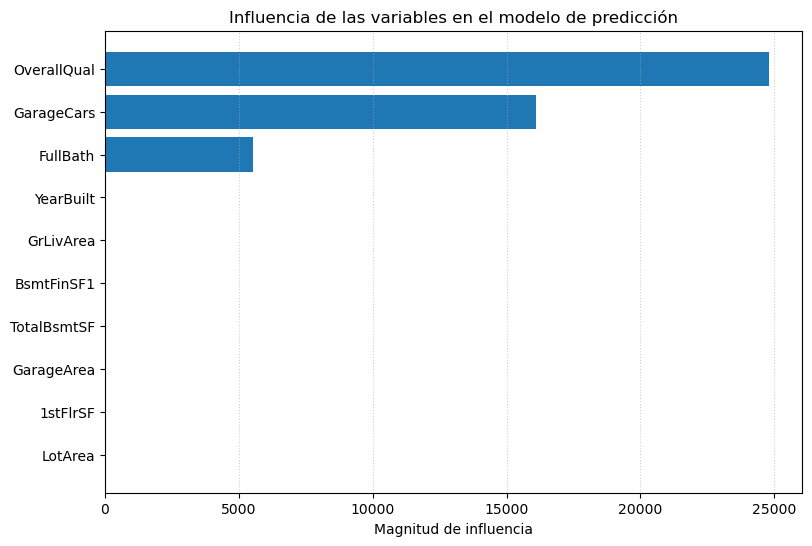

In [7]:
import matplotlib.pyplot as plt


def graficar_influencia_variables(tabla_influencia):
    """
    Grafica la influencia de las variables del modelo de mínimos cuadrados.

    Parámetros:
    tabla_influencia (DataFrame): Tabla con variables y su magnitud de influencia.
    """
    plt.figure(figsize=(9, 6))

    plt.barh(
        tabla_influencia["Variable"],
        tabla_influencia["Influencia (|coeficiente|)"]
    )

    plt.xlabel("Magnitud de influencia")
    plt.title("Influencia de las variables en el modelo de predicción")
    plt.gca().invert_yaxis()
    plt.grid(axis="x", linestyle=":", alpha=0.6)

    plt.show()


# Ejecución de la gráfica
graficar_influencia_variables(tabla_influencia)


In [8]:
import pandas as pd
import numpy as np


def obtener_top_peores_predicciones(df, y, precios_estimados, top_n=10):
    """
    Obtiene las peores predicciones del modelo de mínimos cuadrados
    en función del mayor error absoluto.

    Parámetros:
    df (DataFrame): Dataset completo.
    y (Series): Precios reales.
    precios_estimados (ndarray): Precios estimados por el modelo.
    top_n (int): Número de peores predicciones a mostrar.

    Retorna:
    DataFrame: Tabla con las peores predicciones.
    """
    tabla_resultados = pd.DataFrame({
        "ID": df["Id"],
        "Precio_Real": y.values,
        "Precio_Estimado": precios_estimados
    })

    tabla_resultados["Error"] = (
        tabla_resultados["Precio_Real"] -
        tabla_resultados["Precio_Estimado"]
    )

    tabla_resultados["Error_Absoluto"] = np.abs(
        tabla_resultados["Error"]
    )

    tabla_resultados["Error_Porcentual (%)"] = (
        tabla_resultados["Error_Absoluto"] /
        tabla_resultados["Precio_Real"]
    ) * 100

    top_peores = tabla_resultados.sort_values(
        by="Error_Absoluto",
        ascending=False
    ).head(top_n)

    top_peores = top_peores.sort_values(
        by="Error_Porcentual (%)",
        ascending=True
    )

    print("\nTOP 10 PEORES PREDICCIONES (ORDENADAS POR ERROR PORCENTUAL)")
    print("-----------------------------------------------------------")
    display(top_peores[[
        "ID",
        "Precio_Real",
        "Precio_Estimado",
        "Error",
        "Error_Absoluto",
        "Error_Porcentual (%)"
    ]])

    return top_peores


top_peores = obtener_top_peores_predicciones(df, y, precios_estimados)



TOP 10 PEORES PREDICCIONES (ORDENADAS POR ERROR PORCENTUAL)
-----------------------------------------------------------


,ID,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
440,441,555000,400980.116352,154019.883648,154019.883648,27.751330
769,770,538000,378953.316960,159046.683040,159046.683040,29.562580
1169,1170,625000,437498.268134,187501.731866,187501.731866,30.000277
1182,1183,745000,485806.569574,259193.430426,259193.430426,34.791064
1046,1047,556581,349338.508135,207242.491865,207242.491865,37.234920
691,692,755000,469733.295132,285266.704868,285266.704868,37.783670
898,899,611657,372789.403802,238867.596198,238867.596198,39.052540
803,804,582933,337982.168821,244950.831179,244950.831179,42.020409
523,524,184750,524098.605985,-339348.605985,339348.605985,183.679895
1298,1299,160000,679982.319428,-519982.319428,519982.319428,324.988950


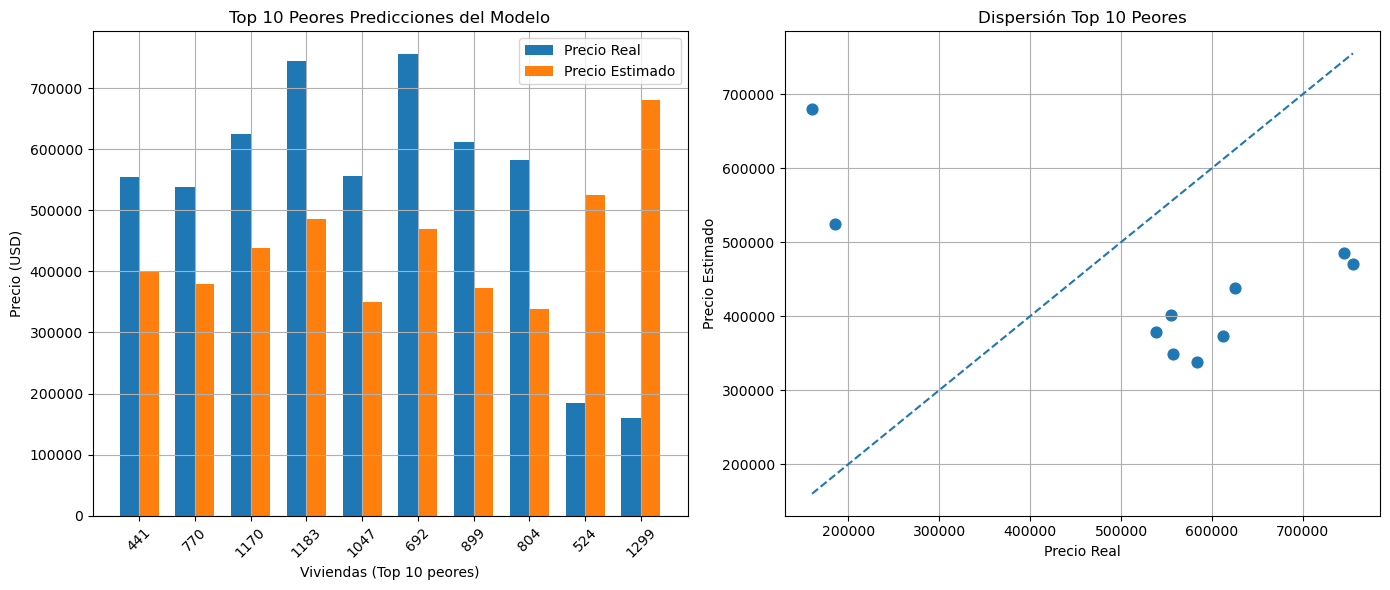

In [9]:
import matplotlib.pyplot as plt
import numpy as np


def graficar_top_peores_predicciones(top_peores):
    """
    Genera dos gráficas para las peores predicciones del modelo:
    1) Gráfico de barras comparando precio real vs estimado.
    2) Gráfico de dispersión precio real vs estimado.

    Parámetros:
    top_peores (DataFrame): Tabla con las peores predicciones.
    """
    ids = top_peores["ID"].astype(str)

    plt.figure(figsize=(14, 6))

    # ============================
    # GRÁFICO 1: BARRAS (IZQUIERDA)
    # ============================
    plt.subplot(1, 2, 1)

    x = np.arange(len(ids))
    width = 0.35

    plt.bar(x - width / 2, top_peores["Precio_Real"], width, label="Precio Real")
    plt.bar(x + width / 2, top_peores["Precio_Estimado"], width, label="Precio Estimado")

    plt.xticks(x, ids, rotation=45)
    plt.xlabel("Viviendas (Top 10 peores)")
    plt.ylabel("Precio (USD)")
    plt.title("Top 10 Peores Predicciones del Modelo")
    plt.legend()
    plt.grid(True)

    # ============================
    # GRÁFICO 2: DISPERSIÓN (DERECHA)
    # ============================
    plt.subplot(1, 2, 2)

    plt.scatter(
        top_peores["Precio_Real"],
        top_peores["Precio_Estimado"],
        s=60
    )

    min_val = min(
        top_peores["Precio_Real"].min(),
        top_peores["Precio_Estimado"].min()
    )

    max_val = max(
        top_peores["Precio_Real"].max(),
        top_peores["Precio_Estimado"].max()
    )

    plt.plot([min_val, max_val], [min_val, max_val], '--')

    plt.xlabel("Precio Real")
    plt.ylabel("Precio Estimado")
    plt.title("Dispersión Top 10 Peores")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# Ejecución de las gráficas
graficar_top_peores_predicciones(top_peores)


In [10]:
def obtener_top_mejores_predicciones(df, y, precios_estimados, top_n=10):
    """
    Obtiene las mejores predicciones del modelo de mínimos cuadrados
    en función del menor error absoluto.

    Parámetros:
    df (DataFrame): Dataset completo.
    y (Series): Precios reales.
    precios_estimados (ndarray): Precios estimados por el modelo.
    top_n (int): Número de mejores predicciones a mostrar.

    Retorna:
    DataFrame: Tabla con las mejores predicciones.
    """
    tabla_resultados = pd.DataFrame({
        "ID": df["Id"],
        "Precio_Real": y.values,
        "Precio_Estimado": precios_estimados
    })

    tabla_resultados["Error"] = (
        tabla_resultados["Precio_Real"] -
        tabla_resultados["Precio_Estimado"]
    )

    tabla_resultados["Error_Absoluto"] = np.abs(
        tabla_resultados["Error"]
    )

    tabla_resultados["Error_Porcentual (%)"] = (
        tabla_resultados["Error_Absoluto"] /
        tabla_resultados["Precio_Real"]
    ) * 100

    top_mejores = tabla_resultados.sort_values(
        by="Error_Absoluto",
        ascending=True
    ).head(top_n)

    top_mejores = top_mejores.sort_values(
        by="Error_Porcentual (%)",
        ascending=True
    )

    print("\nTOP 10 MEJORES PREDICCIONES (ORDENADAS POR ERROR PORCENTUAL)")
    print("------------------------------------------------------------")
    display(top_mejores[[
        "ID",
        "Precio_Real",
        "Precio_Estimado",
        "Error",
        "Error_Absoluto",
        "Error_Porcentual (%)"
    ]])

    return top_mejores


top_mejores = obtener_top_mejores_predicciones(df, y, precios_estimados)



TOP 10 MEJORES PREDICCIONES (ORDENADAS POR ERROR PORCENTUAL)
------------------------------------------------------------


,ID,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
83,84,126500,126499.607491,0.392509,0.392509,0.000310
922,923,169990,170021.146484,-31.146484,31.146484,0.018323
741,742,142000,142041.161441,-41.161441,41.161441,0.028987
356,357,173000,172949.231821,50.768179,50.768179,0.029346
994,995,337500,337399.389100,100.610900,100.610900,0.029811
1203,1204,213000,213088.026225,-88.026225,88.026225,0.041327
924,925,207500,207618.480033,-118.480033,118.480033,0.057099
1032,1033,310000,309683.755983,316.244017,316.244017,0.102014
1207,1208,200000,199726.409376,273.590624,273.590624,0.136795
1206,1207,107000,107224.153036,-224.153036,224.153036,0.209489


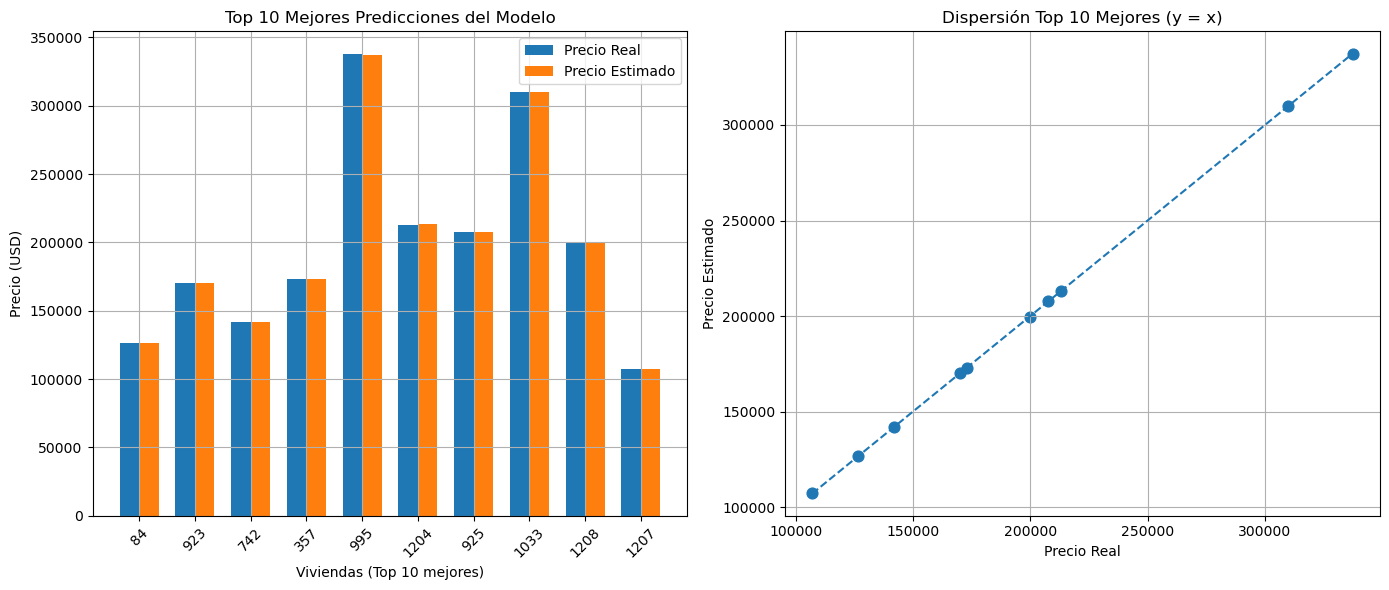

In [11]:
import matplotlib.pyplot as plt
import numpy as np


def graficar_top_mejores_predicciones(top_mejores):
    """
    Genera dos gráficas para las mejores predicciones del modelo:
    1) Gráfico de barras comparando precio real vs estimado.
    2) Gráfico de dispersión precio real vs estimado.

    Parámetros:
    top_mejores (DataFrame): Tabla con las mejores predicciones.
    """
    ids = top_mejores["ID"].astype(str)

    plt.figure(figsize=(14, 6))

    # ============================
    # GRÁFICO 1: BARRAS (IZQUIERDA)
    # ============================
    plt.subplot(1, 2, 1)

    x = np.arange(len(ids))
    width = 0.35

    plt.bar(x - width / 2, top_mejores["Precio_Real"], width, label="Precio Real")
    plt.bar(x + width / 2, top_mejores["Precio_Estimado"], width, label="Precio Estimado")

    plt.xticks(x, ids, rotation=45)
    plt.xlabel("Viviendas (Top 10 mejores)")
    plt.ylabel("Precio (USD)")
    plt.title("Top 10 Mejores Predicciones del Modelo")
    plt.legend()
    plt.grid(True)

    # ============================
    # GRÁFICO 2: DISPERSIÓN (DERECHA)
    # ============================
    plt.subplot(1, 2, 2)

    plt.scatter(
        top_mejores["Precio_Real"],
        top_mejores["Precio_Estimado"],
        s=60
    )

    min_val = min(
        top_mejores["Precio_Real"].min(),
        top_mejores["Precio_Estimado"].min()
    )

    max_val = max(
        top_mejores["Precio_Real"].max(),
        top_mejores["Precio_Estimado"].max()
    )

    plt.plot([min_val, max_val], [min_val, max_val], '--')

    plt.xlabel("Precio Real")
    plt.ylabel("Precio Estimado")
    plt.title("Dispersión Top 10 Mejores (y = x)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# Ejecución de las gráficas
graficar_top_mejores_predicciones(top_mejores)


In [12]:
import numpy as np


def calcular_rmse(y, precios_estimados):
    """
    Calcula el MSE y RMSE del modelo de mínimos cuadrados
    sin normalización.

    Parámetros:
    y (Series): Valores reales del precio.
    precios_estimados (ndarray): Valores estimados por el modelo.

    Retorna:
    tuple: (MSE, RMSE)
    """
    residuos = y.values - precios_estimados
    MSE = np.mean(residuos ** 2)
    RMSE = np.sqrt(MSE)

    print("\nEVALUACIÓN GLOBAL — MODELO SIN NORMALIZAR")
    print("----------------------------------------")
    print(f"MSE: {MSE:,.2f}")
    print(f"RMSE: {RMSE:,.2f} USD")

    return MSE, RMSE


# Ejecución del cálculo
MSE, RMSE = calcular_rmse(y, precios_estimados)



EVALUACIÓN GLOBAL — MODELO SIN NORMALIZAR
----------------------------------------
MSE: 1,421,205,466.70
RMSE: 37,698.88 USD


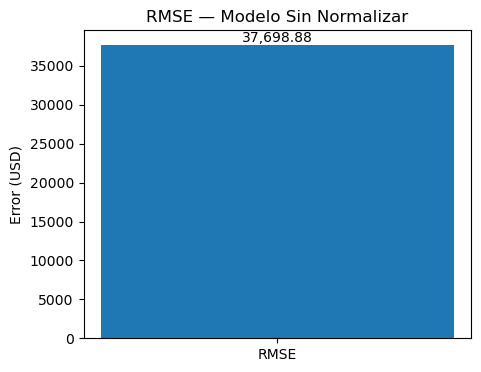

In [13]:
import matplotlib.pyplot as plt


def graficar_rmse(RMSE):
    """
    Grafica el valor del RMSE del modelo de mínimos cuadrados
    sin normalización.

    Parámetros:
    RMSE (float): Valor del error cuadrático medio.
    """
    plt.figure(figsize=(5, 4))

    bars = plt.bar(["RMSE"], [RMSE])

    plt.ylabel("Error (USD)")
    plt.title("RMSE — Modelo Sin Normalizar")

    # Mostrar valor arriba de la barra
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:,.2f}",
            ha="center",
            va="bottom"
        )

    plt.grid(False)
    plt.show()


# Ejecución de la gráfica
graficar_rmse(RMSE)


In [14]:
import pandas as pd
import numpy as np


def generar_tabla_errores(df, y, precios_estimados):
    """
    Genera la tabla de errores por vivienda para el modelo
    de mínimos cuadrados sin normalizar.

    Parámetros:
    df (DataFrame): Dataset completo.
    y (Series): Precios reales.
    precios_estimados (ndarray): Precios estimados por el modelo.

    Retorna:
    DataFrame: Tabla de errores por vivienda.
    """
    precio_real = y.values
    precio_estimado = precios_estimados

    error = precio_real - precio_estimado
    error_abs = np.abs(error)
    error_pct = (error_abs / precio_real) * 100

    tabla_errores = pd.DataFrame({
        "Id": df["Id"],
        "Precio_Real": precio_real,
        "Precio_Estimado": precio_estimado,
        "Error": error,
        "Error_Absoluto": error_abs,
        "Error_Porcentual (%)": error_pct
    })

    tabla_original = tabla_errores.head()
    tabla_original = tabla_original.sort_values(by="Error_Porcentual (%)", ascending=True)

    print("\nTABLA DE ERRORES POR VIVIENDA (MODELO SIN NORMALIZAR)")
    print("-----------------------------------------------------")
    display(tabla_original)

    return tabla_errores


# Ejecución
tabla_errores_sin_norm = generar_tabla_errores(df, y, precios_estimados)



TABLA DE ERRORES POR VIVIENDA (MODELO SIN NORMALIZAR)
-----------------------------------------------------


,Id,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
2,3,223500,217103.247690,6396.752310,6396.752310,2.862082
0,1,208500,215750.493884,-7250.493884,7250.493884,3.477455
1,2,181500,189216.294906,-7716.294906,7716.294906,4.251402
4,5,250000,285253.550739,-35253.550739,35253.550739,14.101420
3,4,140000,221121.843064,-81121.843064,81121.843064,57.944174


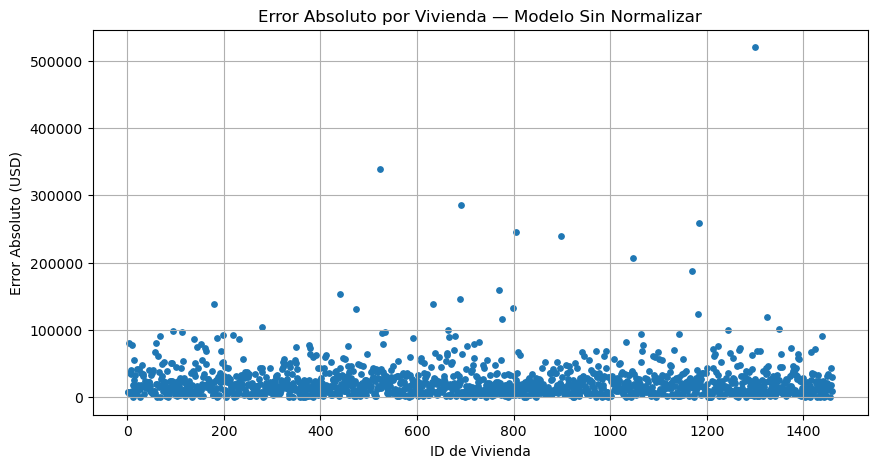

In [15]:
import matplotlib.pyplot as plt


def graficar_error_absoluto_por_vivienda(tabla_errores):
    """
    Grafica el error absoluto por vivienda para el modelo
    de mínimos cuadrados sin normalizar.

    Parámetros:
    tabla_errores (DataFrame): Tabla de errores por vivienda.
    """
    plt.figure(figsize=(10, 5))

    plt.scatter(
        tabla_errores["Id"],
        tabla_errores["Error_Absoluto"],
        s=15
    )

    plt.xlabel("ID de Vivienda")
    plt.ylabel("Error Absoluto (USD)")
    plt.title("Error Absoluto por Vivienda — Modelo Sin Normalizar")
    plt.grid(True)
    plt.show()


# Ejecución de la gráfica
graficar_error_absoluto_por_vivienda(tabla_errores_sin_norm)


**MODELO NORMALIZADO**

In [16]:
import pandas as pd
import numpy as np


def cargar_datos(ruta_archivo):
    """
    Carga el dataset desde un archivo CSV.
    """
    df = pd.read_csv(ruta_archivo, sep=";")
    return df


def separar_y_normalizar(df, columna_objetivo="SalePrice", columna_id="Id"):
    """
    Separa variables, elimina ID y normaliza las variables independientes.
    """
    X = df.drop(columna_objetivo, axis=1)
    y = df[columna_objetivo]

    X = X.drop(columna_id, axis=1)

    media_X = X.mean()
    std_X = X.std()

    X_norm = (X - media_X) / std_X

    return X_norm, y, media_X, std_X


def construir_matriz_modelo(X_norm):
    """
    Construye la matriz A del modelo con término independiente.
    """
    n = X_norm.shape[0]
    columna_unos = np.ones((n, 1))
    A = np.hstack((columna_unos, X_norm.values))
    return A


def calcular_minimos_cuadrados(A, b):
    """
    Calcula los coeficientes del modelo por mínimos cuadrados.
    """
    AT = A.T
    ATA = np.dot(AT, A)
    ATb = np.dot(AT, b)
    coeficientes = np.linalg.solve(ATA, ATb)
    return coeficientes


def predecir(A, coeficientes):
    """
    Realiza la predicción del modelo.
    """
    return np.dot(A, coeficientes)


# ===============================
# EJECUCIÓN DEL MODELO NORMALIZADO
# ===============================

ruta = r"C:\Users\PERSONAL\Desktop\PROYECTO FINAL METODOS NUMERICOS\train.csv"

df = cargar_datos(ruta)

print("\n===============================")
print("DATOS CARGADOS")
print("===============================")
display(df.head())

X_norm, y, media_X, std_X = separar_y_normalizar(df)

print("\n===============================")
print("COLUMNAS DEL MODELO")
print("===============================")
print(X_norm.columns.tolist())

print("\n===============================")
print("PRIMERAS FILAS NORMALIZADAS")
print("===============================")
display(X_norm.head())

A_norm = construir_matriz_modelo(X_norm)
b = y.values

print("\n===============================")
print("DIMENSIÓN DE LA MATRIZ A")
print("===============================")
print(A_norm.shape)

coeficientes_norm = calcular_minimos_cuadrados(A_norm, b)

print("\n===============================")
print("COEFICIENTES DEL MODELO")
print("===============================")
print(coeficientes_norm)

y_pred_norm = predecir(A_norm, coeficientes_norm)

print("\n===============================")
print("PRIMERAS 5 PREDICCIONES")
print("===============================")
print(y_pred_norm[:5])

print("\n===============================")
print("PRIMEROS 5 VALORES REALES")
print("===============================")
print(y.values[:5])



DATOS CARGADOS


,Id,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea,SalePrice
0,1,8450,7,2003,706,856,856,1710,2,2,548,208500
1,2,9600,6,1976,978,1262,1262,1262,2,2,460,181500
2,3,11250,7,2001,486,920,920,1786,2,2,608,223500
3,4,9550,7,1915,216,756,961,1717,1,3,642,140000
4,5,14260,8,2000,655,1145,1145,2198,2,3,836,250000



COLUMNAS DEL MODELO
['LotArea', 'OverallQual', 'YearBuilt', 'BsmtFinSF1', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'FullBath', 'GarageCars', 'GarageArea']

PRIMERAS FILAS NORMALIZADAS


,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea
0,-0.207071,0.651256,1.050634,0.575228,-0.459145,-0.793162,0.370207,0.789470,0.311618,0.350880
1,-0.091855,-0.071812,0.156680,1.171591,0.466305,0.257052,-0.482347,0.789470,0.311618,-0.060710
2,0.073455,0.651256,0.984415,0.092875,-0.313261,-0.627611,0.514836,0.789470,0.311618,0.631510
3,-0.096864,0.651256,-1.862993,-0.499103,-0.687089,-0.521555,0.383528,-1.025689,1.649742,0.790533
4,0.375020,1.374324,0.951306,0.463410,0.199611,-0.045596,1.298881,0.789470,1.649742,1.697903



DIMENSIÓN DE LA MATRIZ A
(1460, 11)

COEFICIENTES DEL MODELO
[180921.19589041   5489.89163307  30539.19917069   9205.37883809
   8489.61515631   4117.05601756   3884.08836123  24888.46720654
  -1040.50647208   9028.5153973    1318.78481358]

PRIMERAS 5 PREDICCIONES
[220925.75382087 182437.79372205 222974.57868018 200586.88094912
 286926.35740752]

PRIMEROS 5 VALORES REALES
[208500 181500 223500 140000 250000]


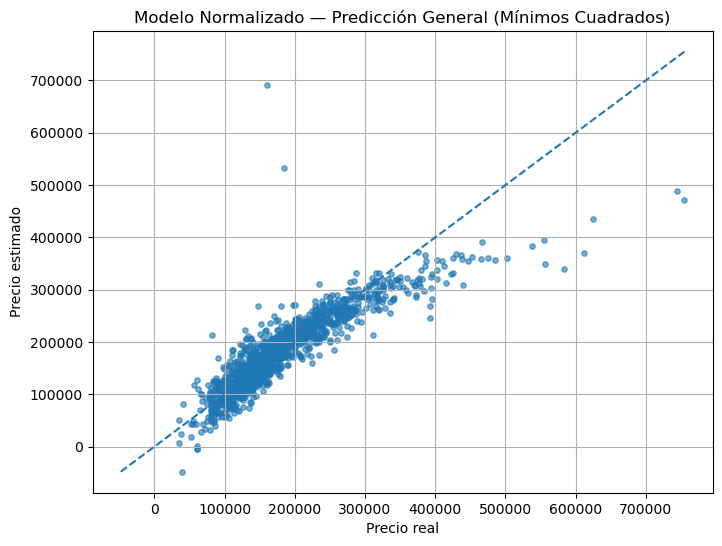

In [17]:
import matplotlib.pyplot as plt


def graficar_prediccion_general_normalizada(y, y_pred_norm):
    """
    Grafica la comparación entre precios reales y precios estimados
    del modelo normalizado por mínimos cuadrados.
    """
    plt.figure(figsize=(8, 6))

    plt.scatter(y, y_pred_norm, alpha=0.6, s=15)

    min_val = min(y.min(), y_pred_norm.min())
    max_val = max(y.max(), y_pred_norm.max())

    plt.plot([min_val, max_val], [min_val, max_val], '--')

    plt.xlabel("Precio real")
    plt.ylabel("Precio estimado")
    plt.title("Modelo Normalizado — Predicción General (Mínimos Cuadrados)")
    plt.grid(True)
    plt.show()


# Ejecución de la gráfica
graficar_prediccion_general_normalizada(y, y_pred_norm)


Ingrese el ID de la vivienda que desea analizar:  1



Datos originales de la vivienda seleccionada:


,Id,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea,SalePrice
0,1,8450,7,2003,706,856,856,1710,2,2,548,208500



RESULTADOS DE LA PREDICCIÓN
-----------------------------
Precio real:      $208,500.00
Precio estimado:  $220,925.75
Error absoluto:   $12,425.75
Error porcentual: 5.96%


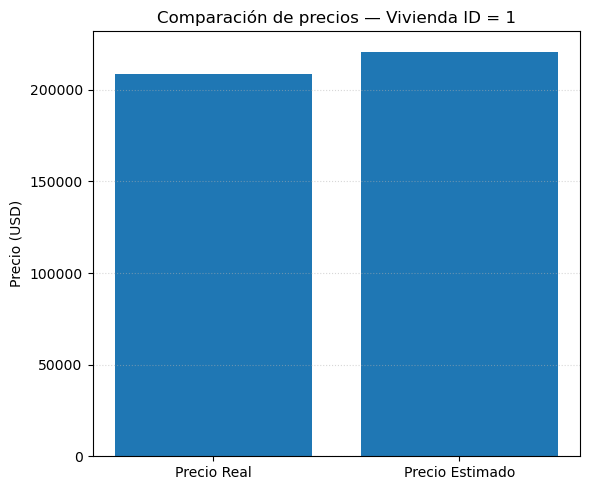

In [18]:
import numpy as np
import matplotlib.pyplot as plt


def predecir_vivienda_normalizada(df, media_X, std_X, coeficientes_norm):
    """
    Realiza la predicción individual de una vivienda usando
    el modelo normalizado y devuelve los valores para la gráfica.
    """
    try:
        id_usuario = int(input("Ingrese el ID de la vivienda que desea analizar: "))

        vivienda = df[df["Id"] == id_usuario]

        if vivienda.empty:
            print(" ID no encontrado en el dataset")
            return None, None, None

        print("\nDatos originales de la vivienda seleccionada:")
        display(vivienda)

        # Preparar datos
        X_vivienda = vivienda.drop(["SalePrice", "Id"], axis=1)
        X_vivienda_norm = (X_vivienda - media_X) / std_X

        fila = X_vivienda_norm.values
        fila = np.hstack(([1], fila[0]))

        # Predicción
        precio_estimado = np.dot(fila, coeficientes_norm)
        precio_real = vivienda["SalePrice"].values[0]

        # Errores
        error_abs = abs(precio_real - precio_estimado)
        error_pct = (error_abs / precio_real) * 100

        print("\nRESULTADOS DE LA PREDICCIÓN")
        print("-----------------------------")
        print(f"Precio real:      ${precio_real:,.2f}")
        print(f"Precio estimado:  ${precio_estimado:,.2f}")
        print(f"Error absoluto:   ${error_abs:,.2f}")
        print(f"Error porcentual: {error_pct:.2f}%")

        return id_usuario, precio_real, precio_estimado

    except ValueError:
        print(" El ID ingresado no es válido.")
        return None, None, None
    except Exception as e:
        print(f"Ocurrió un error durante la predicción: {e}")
        return None, None, None


def graficar_prediccion_individual(id_usuario, precio_real, precio_estimado):
    """
    Grafica Precio Real vs Precio Estimado para una vivienda individual.
    """
    if id_usuario is None:
        return

    plt.figure(figsize=(6, 5))

    valores = [precio_real, precio_estimado]
    etiquetas = ["Precio Real", "Precio Estimado"]

    plt.bar(etiquetas, valores)

    plt.ylabel("Precio (USD)")
    plt.title(f"Comparación de precios — Vivienda ID = {id_usuario}")
    plt.grid(axis="y", linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()


# ===============================
# EJECUCIÓN COMPLETA
# ===============================

id_usuario, precio_real, precio_estimado = predecir_vivienda_normalizada(
    df, media_X, std_X, coeficientes_norm
)

graficar_prediccion_individual(
    id_usuario, precio_real, precio_estimado
)


In [19]:
import pandas as pd
import numpy as np

# ============================================================
# ANÁLISIS DE LA INFLUENCIA DE LAS VARIABLES (MODELO NORMALIZADO)
# ============================================================

# Quitamos el intercepto (primer coeficiente)
coeficientes_variables = coeficientes_norm[1:]

# Nombres correctos de las variables del modelo normalizado
nombres_variables = X_norm.columns.tolist()

# Influencia absoluta
influencia = np.abs(coeficientes_variables)

# Crear tabla resumen
tabla_influencia_norm = pd.DataFrame({
    "Variable": nombres_variables,
    "Coeficiente": coeficientes_variables,
    "Influencia (|coeficiente|)": influencia
})

# Ordenar de mayor a menor influencia
tabla_influencia_norm = tabla_influencia_norm.sort_values(
    by="Influencia (|coeficiente|)",
    ascending=False
)

print("\nINFLUENCIA DE LAS VARIABLES EN EL MODELO NORMALIZADO")
print("------------------------------------------------------")
display(tabla_influencia_norm)




INFLUENCIA DE LAS VARIABLES EN EL MODELO NORMALIZADO
------------------------------------------------------


,Variable,Coeficiente,Influencia (|coeficiente|)
1,OverallQual,30539.199171,30539.199171
6,GrLivArea,24888.467207,24888.467207
2,YearBuilt,9205.378838,9205.378838
8,GarageCars,9028.515397,9028.515397
3,BsmtFinSF1,8489.615156,8489.615156
0,LotArea,5489.891633,5489.891633
4,TotalBsmtSF,4117.056018,4117.056018
5,1stFlrSF,3884.088361,3884.088361
9,GarageArea,1318.784814,1318.784814
7,FullBath,-1040.506472,1040.506472


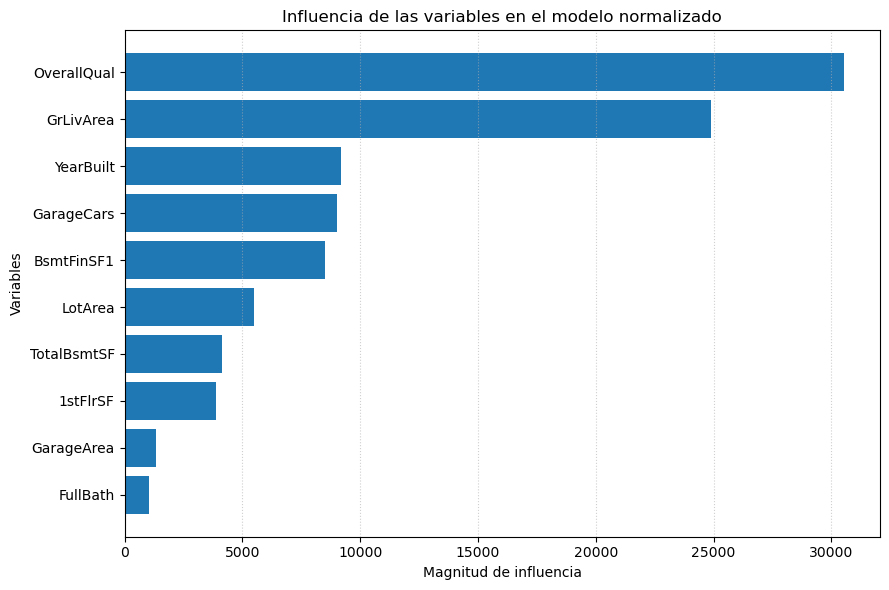

In [20]:
import matplotlib.pyplot as plt


def graficar_influencia_variables_normalizado(tabla_influencia_norm):
    """
    Grafica la influencia de las variables en el modelo normalizado.
    """
    plt.figure(figsize=(9, 6))

    plt.barh(
        tabla_influencia_norm["Variable"],
        tabla_influencia_norm["Influencia (|coeficiente|)"]
    )

    plt.xlabel("Magnitud de influencia")
    plt.ylabel("Variables")
    plt.title("Influencia de las variables en el modelo normalizado")

    plt.gca().invert_yaxis()
    plt.grid(axis="x", linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()


# Ejecución de la gráfica
graficar_influencia_variables_normalizado(tabla_influencia_norm)


In [21]:
import pandas as pd
import numpy as np


def obtener_top_peores_predicciones_normalizado(df, y, y_pred_norm, top_n=10):
    """
    Genera la tabla de las peores predicciones del modelo normalizado
    en función del mayor error absoluto.
    """
    tabla_resultados_norm = pd.DataFrame({
        "ID": df["Id"],
        "Precio_Real": y.values,
        "Precio_Estimado": y_pred_norm
    })

    tabla_resultados_norm["Error"] = (
        tabla_resultados_norm["Precio_Real"] -
        tabla_resultados_norm["Precio_Estimado"]
    )

    tabla_resultados_norm["Error_Absoluto"] = np.abs(
        tabla_resultados_norm["Error"]
    )

    tabla_resultados_norm["Error_Porcentual (%)"] = (
        tabla_resultados_norm["Error_Absoluto"] /
        tabla_resultados_norm["Precio_Real"]
    ) * 100

    top_peores_norm = tabla_resultados_norm.sort_values(
        by="Error_Absoluto",
        ascending=False
    ).head(top_n)

    top_peores_norm = top_peores_norm.sort_values(
        by="Error_Porcentual (%)",
        ascending=True
    )

    print("\nTOP 10 PEORES PREDICCIONES — MODELO NORMALIZADO")
    print("------------------------------------------------")
    display(top_peores_norm[[
        "ID",
        "Precio_Real",
        "Precio_Estimado",
        "Error",
        "Error_Absoluto",
        "Error_Porcentual (%)"
    ]])

    return top_peores_norm


# ===============================
# EJECUCIÓN
# ===============================

top_peores_norm = obtener_top_peores_predicciones_normalizado(
    df, y, y_pred_norm
)



TOP 10 PEORES PREDICCIONES — MODELO NORMALIZADO
------------------------------------------------


,ID,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
769,770,538000,383147.332499,154852.667501,154852.667501,28.783024
440,441,555000,394441.056617,160558.943383,160558.943383,28.929539
1169,1170,625000,434890.542662,190109.457338,190109.457338,30.417513
1182,1183,745000,487765.553754,257234.446246,257234.446246,34.528114
1046,1047,556581,349358.531958,207222.468042,207222.468042,37.231323
691,692,755000,471797.486362,283202.513638,283202.513638,37.510267
898,899,611657,370680.092583,240976.907417,240976.907417,39.397392
803,804,582933,339297.879499,243635.120501,243635.120501,41.794704
523,524,184750,531808.523175,-347058.523175,347058.523175,187.853057
1298,1299,160000,690546.501948,-530546.501948,530546.501948,331.591564


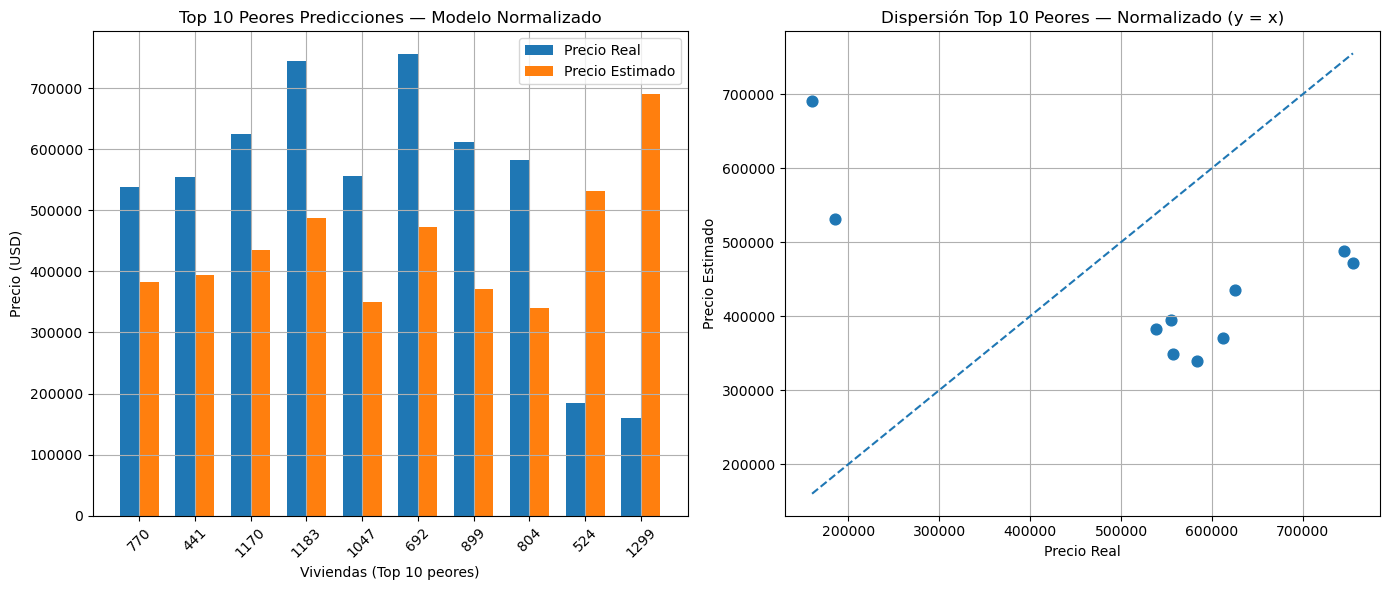

In [22]:
import matplotlib.pyplot as plt
import numpy as np


def graficar_top_peores_predicciones_normalizado(top_peores_norm):
    """
    Genera dos gráficas para las peores predicciones del modelo normalizado:
    1) Gráfico de barras: Precio real vs Precio estimado.
    2) Gráfico de dispersión: Precio real vs Precio estimado (y = x).
    """
    ids_norm = top_peores_norm["ID"].astype(str)

    plt.figure(figsize=(14, 6))

    # ============================
    # GRÁFICO 1: BARRAS (IZQUIERDA)
    # ============================
    plt.subplot(1, 2, 1)

    x = np.arange(len(ids_norm))
    width = 0.35

    plt.bar(x - width / 2, top_peores_norm["Precio_Real"], width, label="Precio Real")
    plt.bar(x + width / 2, top_peores_norm["Precio_Estimado"], width, label="Precio Estimado")

    plt.xticks(x, ids_norm, rotation=45)
    plt.xlabel("Viviendas (Top 10 peores)")
    plt.ylabel("Precio (USD)")
    plt.title("Top 10 Peores Predicciones — Modelo Normalizado")
    plt.legend()
    plt.grid(True)

    # ============================
    # GRÁFICO 2: DISPERSIÓN (DERECHA)
    # ============================
    plt.subplot(1, 2, 2)

    plt.scatter(
        top_peores_norm["Precio_Real"],
        top_peores_norm["Precio_Estimado"],
        s=60
    )

    min_val_norm = min(
        top_peores_norm["Precio_Real"].min(),
        top_peores_norm["Precio_Estimado"].min()
    )

    max_val_norm = max(
        top_peores_norm["Precio_Real"].max(),
        top_peores_norm["Precio_Estimado"].max()
    )

    plt.plot([min_val_norm, max_val_norm], [min_val_norm, max_val_norm], '--')

    plt.xlabel("Precio Real")
    plt.ylabel("Precio Estimado")
    plt.title("Dispersión Top 10 Peores — Normalizado (y = x)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# Ejecución de las gráficas
graficar_top_peores_predicciones_normalizado(top_peores_norm)


In [23]:
import pandas as pd
import numpy as np


def obtener_top_mejores_predicciones_normalizado(df, y, y_pred_norm, top_n=10):
    """
    Genera la tabla de las mejores predicciones del modelo normalizado
    en función del menor error absoluto.
    """
    tabla_resultados_norm = pd.DataFrame({
        "ID": df["Id"],
        "Precio_Real": y.values,
        "Precio_Estimado": y_pred_norm
    })

    tabla_resultados_norm["Error"] = (
        tabla_resultados_norm["Precio_Real"] -
        tabla_resultados_norm["Precio_Estimado"]
    )

    tabla_resultados_norm["Error_Absoluto"] = np.abs(
        tabla_resultados_norm["Error"]
    )

    tabla_resultados_norm["Error_Porcentual (%)"] = (
        tabla_resultados_norm["Error_Absoluto"] /
        tabla_resultados_norm["Precio_Real"]
    ) * 100

    top_mejores_norm = tabla_resultados_norm.sort_values(
        by="Error_Absoluto",
        ascending=True
    ).head(top_n)

    top_mejores_norm = top_mejores_norm.sort_values(
        by="Error_Porcentual (%)",
        ascending=True
    )

    print("\nTOP 10 MEJORES PREDICCIONES — MODELO NORMALIZADO")
    print("------------------------------------------------")
    display(top_mejores_norm[[
        "ID",
        "Precio_Real",
        "Precio_Estimado",
        "Error",
        "Error_Absoluto",
        "Error_Porcentual (%)"
    ]])

    return top_mejores_norm


# ===============================
# EJECUCIÓN
# ===============================

top_mejores_norm = obtener_top_mejores_predicciones_normalizado(
    df, y, y_pred_norm
)


TOP 10 MEJORES PREDICCIONES — MODELO NORMALIZADO
------------------------------------------------


,ID,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
1401,1402,193000,193019.993435,-19.993435,19.993435,0.010359
1051,1052,200141,200113.790020,27.209980,27.209980,0.013595
433,434,181000,181046.548238,-46.548238,46.548238,0.025717
1410,1411,230000,230078.875549,-78.875549,78.875549,0.034294
650,651,205950,206034.822818,-84.822818,84.822818,0.041186
254,255,145000,145119.431719,-119.431719,119.431719,0.082367
1232,1233,101800,101923.457617,-123.457617,123.457617,0.121275
1117,1118,130000,129812.152533,187.847467,187.847467,0.144498
475,476,132500,132696.288408,-196.288408,196.288408,0.148142
386,387,81000,80839.232090,160.767910,160.767910,0.198479


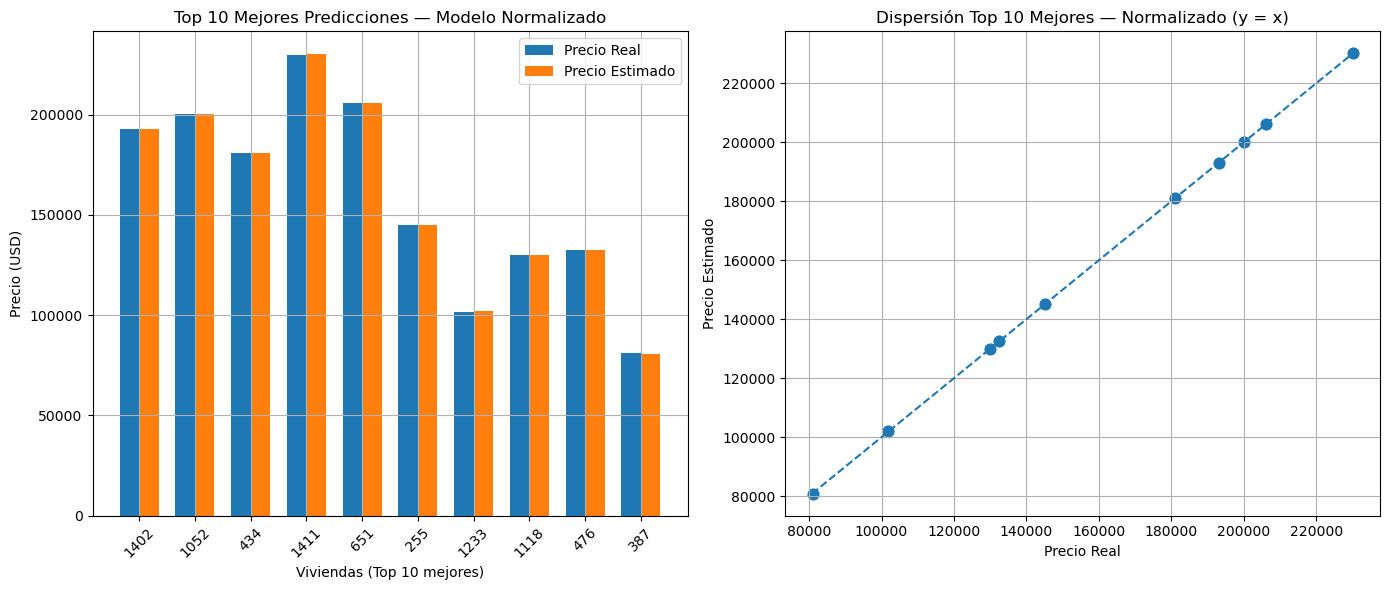

In [24]:
import matplotlib.pyplot as plt
import numpy as np


def graficar_top_mejores_predicciones_normalizado(top_mejores_norm):
    """
    Genera dos gráficas para las mejores predicciones del modelo normalizado:
    1) Gráfico de barras: Precio real vs Precio estimado.
    2) Gráfico de dispersión: Precio real vs Precio estimado (y = x).
    """
    ids_mejores_norm = top_mejores_norm["ID"].astype(str)

    plt.figure(figsize=(14, 6))

    # ============================
    # GRÁFICO 1: BARRAS (IZQUIERDA)
    # ============================
    plt.subplot(1, 2, 1)

    x = np.arange(len(ids_mejores_norm))
    width = 0.35

    plt.bar(x - width / 2, top_mejores_norm["Precio_Real"], width, label="Precio Real")
    plt.bar(x + width / 2, top_mejores_norm["Precio_Estimado"], width, label="Precio Estimado")

    plt.xticks(x, ids_mejores_norm, rotation=45)
    plt.xlabel("Viviendas (Top 10 mejores)")
    plt.ylabel("Precio (USD)")
    plt.title("Top 10 Mejores Predicciones — Modelo Normalizado")
    plt.legend()
    plt.grid(True)

    # ============================
    # GRÁFICO 2: DISPERSIÓN (DERECHA)
    # ============================
    plt.subplot(1, 2, 2)

    plt.scatter(
        top_mejores_norm["Precio_Real"],
        top_mejores_norm["Precio_Estimado"],
        s=60
    )

    min_val_mej = min(
        top_mejores_norm["Precio_Real"].min(),
        top_mejores_norm["Precio_Estimado"].min()
    )

    max_val_mej = max(
        top_mejores_norm["Precio_Real"].max(),
        top_mejores_norm["Precio_Estimado"].max()
    )

    plt.plot([min_val_mej, max_val_mej], [min_val_mej, max_val_mej], '--')

    plt.xlabel("Precio Real")
    plt.ylabel("Precio Estimado")
    plt.title("Dispersión Top 10 Mejores — Normalizado (y = x)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# Ejecución de las gráficas
graficar_top_mejores_predicciones_normalizado(top_mejores_norm)


In [25]:
import numpy as np


def calcular_rmse_normalizado(y, y_pred_norm):
    """
    Calcula el MSE y RMSE del modelo de mínimos cuadrados normalizado.

    Parámetros:
    y (Series): Valores reales del precio.
    y_pred_norm (ndarray): Valores estimados por el modelo normalizado.

    Retorna:
    tuple: (MSE_norm, RMSE_norm)
    """
    residuos_norm = y.values - y_pred_norm
    MSE_norm = np.mean(residuos_norm ** 2)
    RMSE_norm = np.sqrt(MSE_norm)

    print("\nEVALUACIÓN GLOBAL — MODELO NORMALIZADO")
    print("---------------------------------------")
    print(f"MSE:  {MSE_norm:,.2f}")
    print(f"RMSE: {RMSE_norm:,.2f} USD")

    return MSE_norm, RMSE_norm


# Ejecución del cálculo
MSE_norm, RMSE_norm = calcular_rmse_normalizado(y, y_pred_norm)



EVALUACIÓN GLOBAL — MODELO NORMALIZADO
---------------------------------------
MSE:  1,366,063,846.28
RMSE: 36,960.30 USD


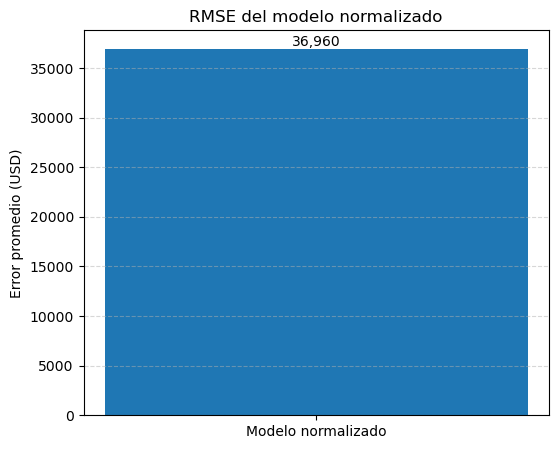

In [26]:
import matplotlib.pyplot as plt


def graficar_rmse_normalizado(RMSE_norm):
    """
    Grafica el RMSE del modelo normalizado.
    """
    plt.figure(figsize=(6, 5))

    plt.bar(["Modelo normalizado"], [RMSE_norm])

    plt.ylabel("Error promedio (USD)")
    plt.title("RMSE del modelo normalizado")

    # Mostrar valor encima de la barra
    plt.text(
        0,
        RMSE_norm,
        f"{RMSE_norm:,.0f}",
        ha="center",
        va="bottom"
    )

    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()


# Ejecución de la gráfica
graficar_rmse_normalizado(RMSE_norm)


In [27]:
import pandas as pd
import numpy as np


def generar_tabla_errores_normalizado(df, y, y_pred_norm):
    """
    Genera la tabla de errores por vivienda para el modelo
    de mínimos cuadrados normalizado.

    Parámetros:
    df (DataFrame): Dataset completo.
    y (Series): Precios reales.
    y_pred_norm (ndarray): Precios estimados por el modelo normalizado.

    Retorna:
    DataFrame: Tabla de errores por vivienda.
    """
    precio_real = y.values
    precio_estimado = y_pred_norm

    error = precio_real - precio_estimado
    error_abs = np.abs(error)
    error_pct = (error_abs / precio_real) * 100

    tabla_errores_norm = pd.DataFrame({
        "Id": df["Id"],
        "Precio_Real": precio_real,
        "Precio_Estimado": precio_estimado,
        "Error": error,
        "Error_Absoluto": error_abs,
        "Error_Porcentual (%)": error_pct
    })

    tabla_original = tabla_errores_norm.head()
    tabla_original = tabla_original.sort_values(
        by="Error_Porcentual (%)",
        ascending=True
    )

    print("\nTABLA DE ERRORES POR VIVIENDA (MODELO NORMALIZADO)")
    print("---------------------------------------------------")
    display(tabla_original)

    return tabla_errores_norm


# Ejecución
tabla_errores_norm = generar_tabla_errores_normalizado(df, y, y_pred_norm)


TABLA DE ERRORES POR VIVIENDA (MODELO NORMALIZADO)
---------------------------------------------------


,Id,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
2,3,223500,222974.578680,525.421320,525.421320,0.235088
1,2,181500,182437.793722,-937.793722,937.793722,0.516691
0,1,208500,220925.753821,-12425.753821,12425.753821,5.959594
4,5,250000,286926.357408,-36926.357408,36926.357408,14.770543
3,4,140000,200586.880949,-60586.880949,60586.880949,43.276344


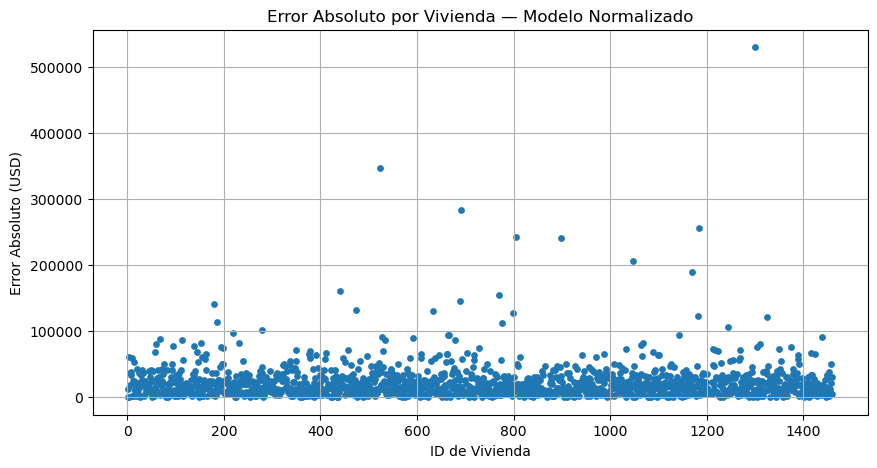

In [28]:
import matplotlib.pyplot as plt


def graficar_error_absoluto_por_vivienda_normalizado(tabla_errores_norm):
    """
    Grafica el error absoluto por vivienda para el modelo normalizado.
    """
    plt.figure(figsize=(10, 5))

    plt.scatter(
        tabla_errores_norm["Id"],
        tabla_errores_norm["Error_Absoluto"],
        s=15
    )

    plt.xlabel("ID de Vivienda")
    plt.ylabel("Error Absoluto (USD)")
    plt.title("Error Absoluto por Vivienda — Modelo Normalizado")
    plt.grid(True)
    plt.show()


# Ejecución de la gráfica
graficar_error_absoluto_por_vivienda_normalizado(tabla_errores_norm)


**MODELO 3**

In [29]:
import numpy as np


def limpiar_outliers_boxplot(df, columna_objetivo="SalePrice"):
    """
    Elimina valores atípicos utilizando el método del rango
    intercuartílico (IQR) sobre la variable objetivo.

    Parámetros:
    df (DataFrame): Dataset original.
    columna_objetivo (str): Variable sobre la cual se aplica el boxplot.

    Retorna:
    DataFrame: Dataset sin valores atípicos.
    """
    precios = df[columna_objetivo].values

    # Cuartiles
    Q1 = np.percentile(precios, 25)
    Q3 = np.percentile(precios, 75)

    # Rango intercuartílico
    IQR = Q3 - Q1

    # Límites del boxplot
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print("\nLÍMITES DEL BOXPLOT")
    print("--------------------")
    print(f"Límite inferior: {limite_inferior}")
    print(f"Límite superior: {limite_superior}")

    # Dataset limpio
    df_limpio = df[
        (df[columna_objetivo] >= limite_inferior) &
        (df[columna_objetivo] <= limite_superior)
    ].copy()

    print("\nRESUMEN LIMPIEZA")
    print("----------------")
    print("Datos originales:", len(df))
    print("Datos después del boxplot:", len(df_limpio))

    return df_limpio, limite_inferior, limite_superior


# ===============================
# EJECUCIÓN — MODELO 3
# ===============================

df_m3, limite_inferior, limite_superior = limpiar_outliers_boxplot(df)



LÍMITES DEL BOXPLOT
--------------------
Límite inferior: 3937.5
Límite superior: 340037.5

RESUMEN LIMPIEZA
----------------
Datos originales: 1460
Datos después del boxplot: 1399


In [30]:
import numpy as np


def entrenar_modelo_3(df_m3, columna_objetivo="SalePrice", columna_id="Id"):
    """
    Entrena el Modelo 3 utilizando datos limpios (boxplot)
    y normalización de variables independientes.
    """
    # ===============================
    # SEPARACIÓN DE VARIABLES
    # ===============================
    X_m3 = df_m3.drop(columna_objetivo, axis=1)
    y_m3 = df_m3[columna_objetivo]

    X_m3 = X_m3.drop(columna_id, axis=1)

    print("\nCOLUMNAS DEL MODELO 3")
    print("----------------------")
    print(X_m3.columns.tolist())

    # ===============================
    # NORMALIZACIÓN
    # ===============================
    media_X_m3 = X_m3.mean()
    std_X_m3 = X_m3.std()

    X_m3_norm = (X_m3 - media_X_m3) / std_X_m3

    print("\nPRIMERAS FILAS NORMALIZADAS (MODELO 3)")
    print("-------------------------------------")
    display(X_m3_norm.head())

    # ===============================
    # MATRIZ DEL MODELO
    # ===============================
    n_m3 = X_m3_norm.shape[0]
    columna_unos_m3 = np.ones((n_m3, 1))
    A_m3 = np.hstack((columna_unos_m3, X_m3_norm.values))
    b_m3 = y_m3.values

    print("\nDIMENSIÓN MATRIZ A (MODELO 3)")
    print("------------------------------")
    print(A_m3.shape)

    # ===============================
    # MÍNIMOS CUADRADOS
    # ===============================
    AT_m3 = A_m3.T
    ATA_m3 = np.dot(AT_m3, A_m3)
    ATb_m3 = np.dot(AT_m3, b_m3)

    coeficientes_m3 = np.linalg.solve(ATA_m3, ATb_m3)

    print("\nCOEFICIENTES MODELO 3")
    print("----------------------")
    print(coeficientes_m3)

    # ===============================
    # PREDICCIÓN GENERAL
    # ===============================
    y_pred_m3 = np.dot(A_m3, coeficientes_m3)

    print("\nPRIMERAS 5 PREDICCIONES MODELO 3")
    print("--------------------------------")
    print(y_pred_m3[:5])

    print("\nPRIMEROS 5 VALORES REALES MODELO 3")
    print("----------------------------------")
    print(y_m3.values[:5])

    return (
        X_m3,
        y_m3,
        X_m3_norm,
        media_X_m3,
        std_X_m3,
        A_m3,
        coeficientes_m3,
        y_pred_m3
    )


# ===============================
# EJECUCIÓN MODELO 3
# ===============================

(
    X_m3,
    y_m3,
    X_m3_norm,
    media_X_m3,
    std_X_m3,
    A_m3,
    coeficientes_m3,
    y_pred_m3
) = entrenar_modelo_3(df_m3)



COLUMNAS DEL MODELO 3
----------------------
['LotArea', 'OverallQual', 'YearBuilt', 'BsmtFinSF1', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'FullBath', 'GarageCars', 'GarageArea']

PRIMERAS FILAS NORMALIZADAS (MODELO 3)
-------------------------------------


,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea
0,-0.204843,0.792687,1.096962,0.673823,-0.413417,-0.773113,0.490240,0.855544,0.391403,0.436575
1,-0.066702,0.012821,0.197245,1.308741,0.584048,0.363129,-0.442020,0.855544,0.391403,0.005791
2,0.131500,0.792687,1.030316,0.160286,-0.256181,-0.594001,0.648392,0.855544,0.391403,0.730292
3,-0.072708,0.792687,-1.835447,-0.469963,-0.659098,-0.479257,0.504807,-1.005896,1.777664,0.896731
4,0.493069,1.572553,0.996993,0.554776,0.296601,0.035690,1.505738,0.855544,1.777664,1.846414



DIMENSIÓN MATRIZ A (MODELO 3)
------------------------------
(1399, 11)

COEFICIENTES MODELO 3
----------------------
[170237.12723374   5022.39571569  23459.84609448  10376.7172412
   4607.65227272   2539.57377678   1514.73937857  16844.94201972
    872.71108983   6801.49102495   2143.03528946]

PRIMERAS 5 PREDICCIONES MODELO 3
--------------------------------
[212673.70620133 176288.54440213 215269.30744031 186495.23071231
 265472.79888985]

PRIMEROS 5 VALORES REALES MODELO 3
----------------------------------
[208500 181500 223500 140000 250000]


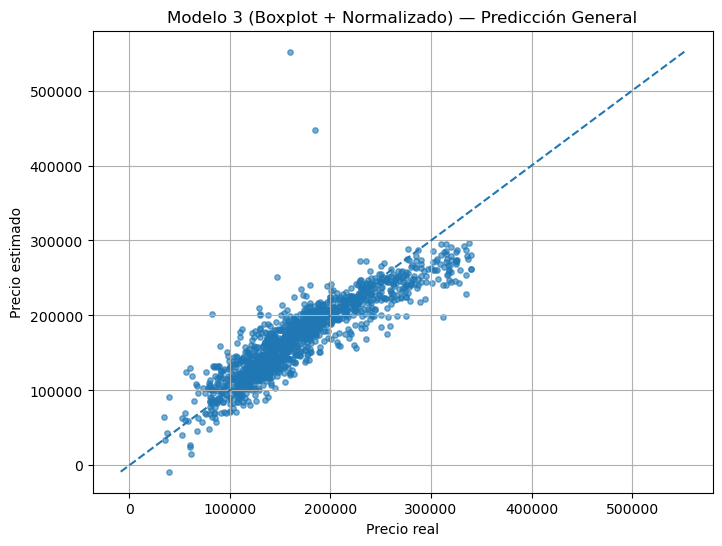

In [31]:
import matplotlib.pyplot as plt


def graficar_prediccion_general_modelo_3(y_m3, y_pred_m3):
    """
    Grafica la comparación entre precios reales y precios estimados
    del Modelo 3 (Boxplot + Normalización).
    """
    plt.figure(figsize=(8, 6))

    plt.scatter(y_m3, y_pred_m3, alpha=0.6, s=15)

    min_val_m3 = min(y_m3.min(), y_pred_m3.min())
    max_val_m3 = max(y_m3.max(), y_pred_m3.max())

    plt.plot([min_val_m3, max_val_m3], [min_val_m3, max_val_m3], '--')

    plt.xlabel("Precio real")
    plt.ylabel("Precio estimado")
    plt.title("Modelo 3 (Boxplot + Normalizado) — Predicción General")
    plt.grid(True)
    plt.show()


# Ejecución de la gráfica
graficar_prediccion_general_modelo_3(y_m3, y_pred_m3)


In [32]:
import numpy as np


def predecir_vivienda_modelo_3(df_m3, media_X_m3, std_X_m3, coeficientes_m3):
    """
    Realiza la predicción individual de una vivienda usando el MODELO 3
    (datos limpios con boxplot + normalización).

    Parámetros:
    df_m3 (DataFrame): Dataset limpio del modelo 3.
    media_X_m3 (Series): Media usada en la normalización del modelo 3.
    std_X_m3 (Series): Desviación estándar usada en la normalización del modelo 3.
    coeficientes_m3 (ndarray): Coeficientes del modelo 3.

    Retorna:
    tuple: (id_usuario_m3, precio_real_m3, precio_estimado_m3)
    """
    try:
        id_usuario_m3 = int(input(
            "Ingrese el ID de la vivienda que desea analizar (MODELO 3): "
        ))

        vivienda_m3 = df_m3[df_m3["Id"] == id_usuario_m3]

        if vivienda_m3.empty:
            print(" ID no encontrado (puede haber sido eliminado por el boxplot)")
            return None, None, None

        print("\nDatos originales de la vivienda seleccionada (MODELO 3):")
        display(vivienda_m3)

        # Preparar datos
        X_vivienda_m3 = vivienda_m3.drop(["SalePrice", "Id"], axis=1)

        # Normalización con parámetros del MODELO 3
        X_vivienda_norm_m3 = (X_vivienda_m3 - media_X_m3) / std_X_m3

        # Vector del modelo
        fila_m3 = X_vivienda_norm_m3.values
        fila_m3 = np.hstack(([1], fila_m3[0]))

        # Predicción
        precio_estimado_m3 = np.dot(fila_m3, coeficientes_m3)
        precio_real_m3 = vivienda_m3["SalePrice"].values[0]

        # Errores
        error_abs_m3 = abs(precio_real_m3 - precio_estimado_m3)
        error_pct_m3 = (error_abs_m3 / precio_real_m3) * 100

        print("\nRESULTADOS DE LA PREDICCIÓN — MODELO 3")
        print("--------------------------------------")
        print(f"Precio real:      ${precio_real_m3:,.2f}")
        print(f"Precio estimado:  ${precio_estimado_m3:,.2f}")
        print(f"Error absoluto:   ${error_abs_m3:,.2f}")
        print(f"Error porcentual: {error_pct_m3:.2f}%")

        return id_usuario_m3, precio_real_m3, precio_estimado_m3

    except ValueError:
        print(" El ID ingresado no es válido.")
        return None, None, None
    except Exception as e:
        print(f"Ocurrió un error durante la predicción: {e}")
        return None, None, None


# ===============================
# EJECUCIÓN — PREDICCIÓN INDIVIDUAL MODELO 3
# ===============================

id_usuario_m3, precio_real_m3, precio_estimado_m3 = predecir_vivienda_modelo_3(
    df_m3, media_X_m3, std_X_m3, coeficientes_m3
)


Ingrese el ID de la vivienda que desea analizar (MODELO 3):  1



Datos originales de la vivienda seleccionada (MODELO 3):


,Id,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea,SalePrice
0,1,8450,7,2003,706,856,856,1710,2,2,548,208500



RESULTADOS DE LA PREDICCIÓN — MODELO 3
--------------------------------------
Precio real:      $208,500.00
Precio estimado:  $212,673.71
Error absoluto:   $4,173.71
Error porcentual: 2.00%


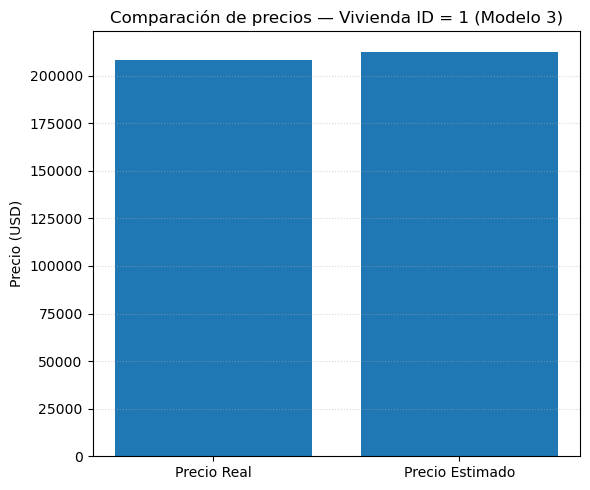

In [33]:
import matplotlib.pyplot as plt


def graficar_prediccion_individual_modelo_3(id_usuario_m3, precio_real_m3, precio_estimado_m3):
    """
    Grafica la comparación entre el precio real y el precio estimado
    para una vivienda específica usando el MODELO 3.
    """
    if id_usuario_m3 is None:
        return

    plt.figure(figsize=(6, 5))

    valores = [precio_real_m3, precio_estimado_m3]
    etiquetas = ["Precio Real", "Precio Estimado"]

    plt.bar(etiquetas, valores)

    plt.ylabel("Precio (USD)")
    plt.title(f"Comparación de precios — Vivienda ID = {id_usuario_m3} (Modelo 3)")
    plt.grid(axis="y", linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()


# ===============================
# EJECUCIÓN DE LA GRÁFICA — MODELO 3
# ===============================

graficar_prediccion_individual_modelo_3(
    id_usuario_m3,
    precio_real_m3,
    precio_estimado_m3
)


In [34]:
import pandas as pd
import numpy as np


def analizar_influencia_variables_modelo_3(X_m3, coeficientes_m3):
    """
    Analiza la influencia de las variables en el MODELO 3
    (datos limpios + normalización) a partir de los coeficientes.

    Parámetros:
    X_m3 (DataFrame): Variables independientes del modelo 3.
    coeficientes_m3 (ndarray): Coeficientes del modelo 3.

    Retorna:
    DataFrame: Tabla ordenada por nivel de influencia.
    """
    # Excluir intercepto
    coeficientes_vars_m3 = coeficientes_m3[1:]

    # Nombres de variables (coinciden con los coeficientes)
    nombres_vars_m3 = X_m3.columns.tolist()

    # Magnitud de influencia
    influencia_m3 = np.abs(coeficientes_vars_m3)

    tabla_influencia_m3 = pd.DataFrame({
        "Variable": nombres_vars_m3,
        "Coeficiente": coeficientes_vars_m3,
        "Influencia (|coeficiente|)": influencia_m3
    })

    tabla_influencia_m3 = tabla_influencia_m3.sort_values(
        by="Influencia (|coeficiente|)",
        ascending=False
    )

    print("\nINFLUENCIA DE VARIABLES — MODELO 3")
    print("----------------------------------")
    display(tabla_influencia_m3)

    return tabla_influencia_m3


# ===============================
# EJECUCIÓN — MODELO 3
# ===============================

tabla_influencia_m3 = analizar_influencia_variables_modelo_3(
    X_m3, coeficientes_m3
)



INFLUENCIA DE VARIABLES — MODELO 3
----------------------------------


,Variable,Coeficiente,Influencia (|coeficiente|)
1,OverallQual,23459.846094,23459.846094
6,GrLivArea,16844.942020,16844.942020
2,YearBuilt,10376.717241,10376.717241
8,GarageCars,6801.491025,6801.491025
0,LotArea,5022.395716,5022.395716
3,BsmtFinSF1,4607.652273,4607.652273
4,TotalBsmtSF,2539.573777,2539.573777
9,GarageArea,2143.035289,2143.035289
5,1stFlrSF,1514.739379,1514.739379
7,FullBath,872.711090,872.711090


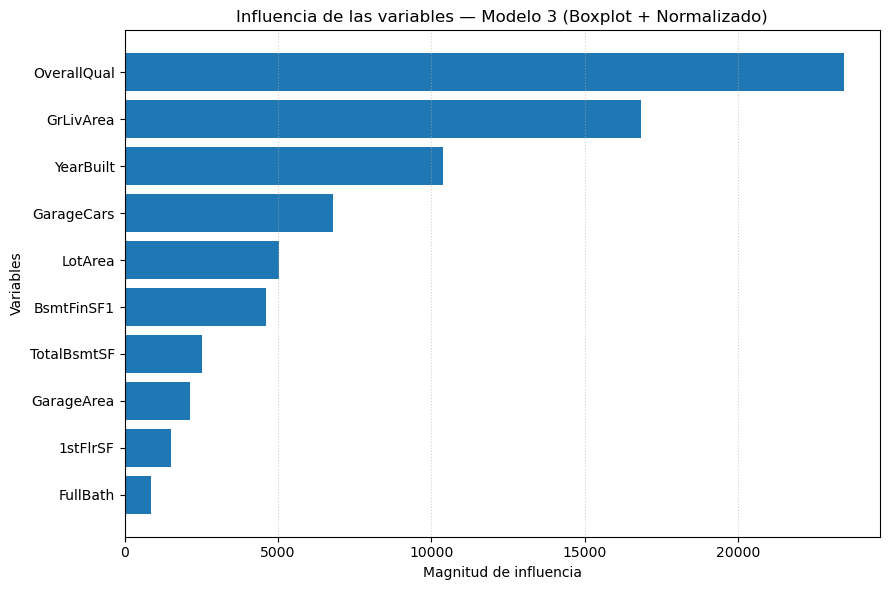

In [35]:
import matplotlib.pyplot as plt


def graficar_influencia_variables_modelo_3(tabla_influencia_m3):
    """
    Grafica la influencia de las variables del MODELO 3
    (Boxplot + Normalización).
    """
    plt.figure(figsize=(9, 6))

    plt.barh(
        tabla_influencia_m3["Variable"],
        tabla_influencia_m3["Influencia (|coeficiente|)"]
    )

    plt.xlabel("Magnitud de influencia")
    plt.ylabel("Variables")
    plt.title("Influencia de las variables — Modelo 3 (Boxplot + Normalizado)")

    # Variables más influyentes arriba
    plt.gca().invert_yaxis()

    plt.grid(axis="x", linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()


# ===============================
# EJECUCIÓN — GRÁFICA MODELO 3
# ===============================

graficar_influencia_variables_modelo_3(tabla_influencia_m3)


In [36]:
import pandas as pd
import numpy as np


def obtener_top_peores_predicciones_modelo_3(df_m3, y_m3, y_pred_m3, top_n=10):
    """
    Genera la tabla de las peores predicciones del MODELO 3
    (boxplot + normalización) en función del mayor error absoluto.
    """
    tabla_resultados_m3 = pd.DataFrame({
        "ID": df_m3["Id"],
        "Precio_Real": y_m3.values,
        "Precio_Estimado": y_pred_m3
    })

    tabla_resultados_m3["Error"] = (
        tabla_resultados_m3["Precio_Real"] -
        tabla_resultados_m3["Precio_Estimado"]
    )

    tabla_resultados_m3["Error_Absoluto"] = np.abs(
        tabla_resultados_m3["Error"]
    )

    tabla_resultados_m3["Error_Porcentual (%)"] = (
        tabla_resultados_m3["Error_Absoluto"] /
        tabla_resultados_m3["Precio_Real"]
    ) * 100

    top_peores_m3 = tabla_resultados_m3.sort_values(
        by="Error_Absoluto",
        ascending=False
    ).head(top_n)

    top_peores_m3 = top_peores_m3.sort_values(
        by="Error_Porcentual (%)",
        ascending=True
    )

    print("\nTOP 10 PEORES PREDICCIONES — MODELO 3")
    print("--------------------------------------")
    display(top_peores_m3[[
        "ID",
        "Precio_Real",
        "Precio_Estimado",
        "Error",
        "Error_Absoluto",
        "Error_Porcentual (%)"
    ]])

    return top_peores_m3


# ===============================
# EJECUCIÓN — MODELO 3
# ===============================

top_peores_m3 = obtener_top_peores_predicciones_modelo_3(
    df_m3, y_m3, y_pred_m3
)



TOP 10 PEORES PREDICCIONES — MODELO 3
--------------------------------------


,ID,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
692,693,335000,254339.211523,80660.788477,80660.788477,24.077847
1065,1066,328000,242762.756869,85237.243131,85237.243131,25.986964
457,458,256000,175386.884143,80613.115857,80613.115857,31.489498
1310,1311,335000,228338.026127,106661.973873,106661.973873,31.839395
218,219,311500,197498.186564,114001.813436,114001.813436,36.597693
666,667,129000,209289.831457,-80289.831457,80289.831457,62.240179
1324,1325,147000,251227.619519,-104227.619519,104227.619519,70.903143
523,524,184750,447206.174709,-262456.174709,262456.174709,142.060176
632,633,82500,202149.070495,-119649.070495,119649.070495,145.029176
1298,1299,160000,551843.919120,-391843.919120,391843.919120,244.902449


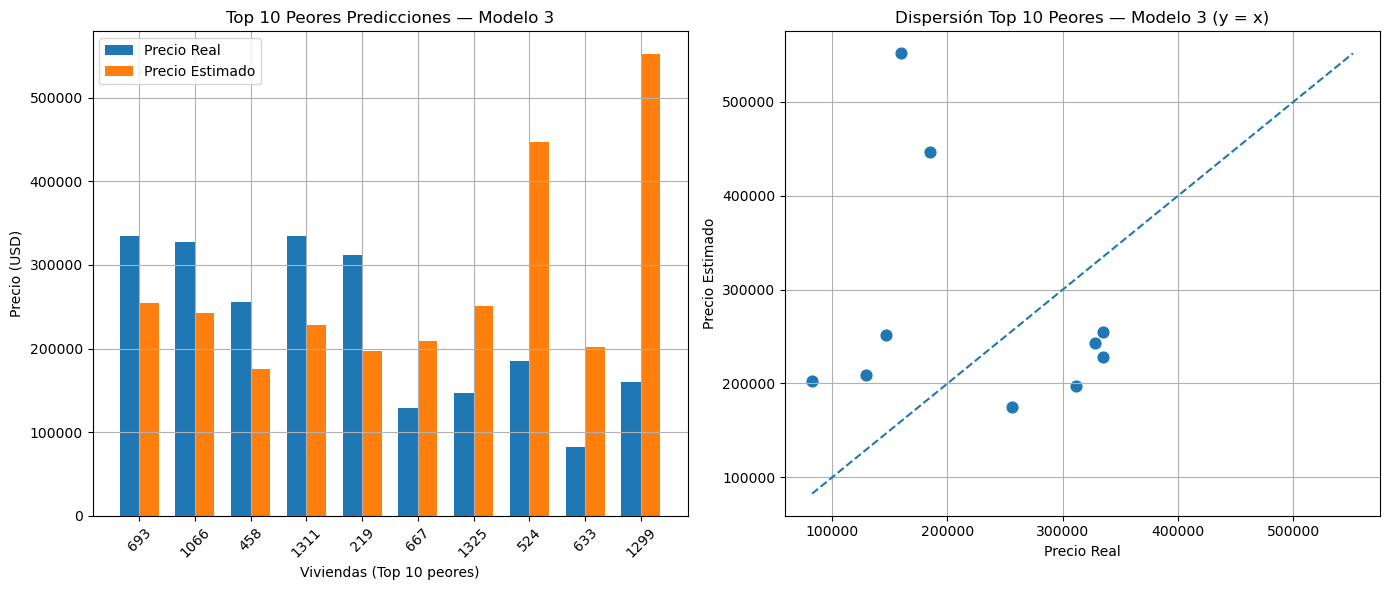

In [37]:
import matplotlib.pyplot as plt
import numpy as np


def graficar_top_peores_predicciones_modelo_3(top_peores_m3):
    """
    Genera las gráficas del TOP 10 de peores predicciones del MODELO 3:
    1) Gráfico de barras: Precio real vs Precio estimado.
    2) Gráfico de dispersión: Precio real vs Precio estimado (y = x).
    """
    ids_m3 = top_peores_m3["ID"].astype(str)

    plt.figure(figsize=(14, 6))

    # ============================
    # GRÁFICO 1: BARRAS
    # ============================
    plt.subplot(1, 2, 1)

    x = np.arange(len(ids_m3))
    width = 0.35

    plt.bar(x - width / 2, top_peores_m3["Precio_Real"], width, label="Precio Real")
    plt.bar(x + width / 2, top_peores_m3["Precio_Estimado"], width, label="Precio Estimado")

    plt.xticks(x, ids_m3, rotation=45)
    plt.xlabel("Viviendas (Top 10 peores)")
    plt.ylabel("Precio (USD)")
    plt.title("Top 10 Peores Predicciones — Modelo 3")
    plt.legend()
    plt.grid(True)

    # ============================
    # GRÁFICO 2: DISPERSIÓN
    # ============================
    plt.subplot(1, 2, 2)

    plt.scatter(
        top_peores_m3["Precio_Real"],
        top_peores_m3["Precio_Estimado"],
        s=60
    )

    min_val_m3 = min(
        top_peores_m3["Precio_Real"].min(),
        top_peores_m3["Precio_Estimado"].min()
    )

    max_val_m3 = max(
        top_peores_m3["Precio_Real"].max(),
        top_peores_m3["Precio_Estimado"].max()
    )

    plt.plot([min_val_m3, max_val_m3], [min_val_m3, max_val_m3], '--')

    plt.xlabel("Precio Real")
    plt.ylabel("Precio Estimado")
    plt.title("Dispersión Top 10 Peores — Modelo 3 (y = x)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# ===============================
# EJECUCIÓN — GRÁFICAS MODELO 3
# ===============================

graficar_top_peores_predicciones_modelo_3(top_peores_m3)


In [38]:
import pandas as pd
import numpy as np


def obtener_top_mejores_predicciones_modelo_3(df_m3, y_m3, y_pred_m3, top_n=10):
    """
    Genera la tabla de las mejores predicciones del MODELO 3
    (boxplot + normalización) en función del menor error absoluto.
    """
    tabla_resultados_m3 = pd.DataFrame({
        "ID": df_m3["Id"],
        "Precio_Real": y_m3.values,
        "Precio_Estimado": y_pred_m3
    })

    tabla_resultados_m3["Error"] = (
        tabla_resultados_m3["Precio_Real"] -
        tabla_resultados_m3["Precio_Estimado"]
    )

    tabla_resultados_m3["Error_Absoluto"] = np.abs(
        tabla_resultados_m3["Error"]
    )

    tabla_resultados_m3["Error_Porcentual (%)"] = (
        tabla_resultados_m3["Error_Absoluto"] /
        tabla_resultados_m3["Precio_Real"]
    ) * 100

    top_mejores_m3 = tabla_resultados_m3.sort_values(
        by="Error_Absoluto",
        ascending=True
    ).head(top_n)

    top_mejores_m3 = top_mejores_m3.sort_values(
        by="Error_Porcentual (%)",
        ascending=True
    )

    print("\nTOP 10 MEJORES PREDICCIONES — MODELO 3")
    print("--------------------------------------")
    display(top_mejores_m3[[
        "ID",
        "Precio_Real",
        "Precio_Estimado",
        "Error",
        "Error_Absoluto",
        "Error_Porcentual (%)"
    ]])

    return top_mejores_m3


# ===============================
# EJECUCIÓN — MODELO 3
# ===============================

top_mejores_m3 = obtener_top_mejores_predicciones_modelo_3(
    df_m3, y_m3, y_pred_m3
)


TOP 10 MEJORES PREDICCIONES — MODELO 3
--------------------------------------


,ID,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
1407,1408,112000,111973.037876,26.962124,26.962124,0.024073
1154,1155,201800,201879.773864,-79.773864,79.773864,0.039531
1001,1002,86000,85965.057038,34.942962,34.942962,0.040631
880,881,157000,156927.218274,72.781726,72.781726,0.046358
360,361,156000,155926.999145,73.000855,73.000855,0.046795
334,335,192000,191909.080188,90.919812,90.919812,0.047354
1041,1042,173000,173086.485005,-86.485005,86.485005,0.049991
872,873,116000,115937.237140,62.762860,62.762860,0.054106
61,62,101000,101057.886056,-57.886056,57.886056,0.057313
587,588,137000,136918.029553,81.970447,81.970447,0.059832


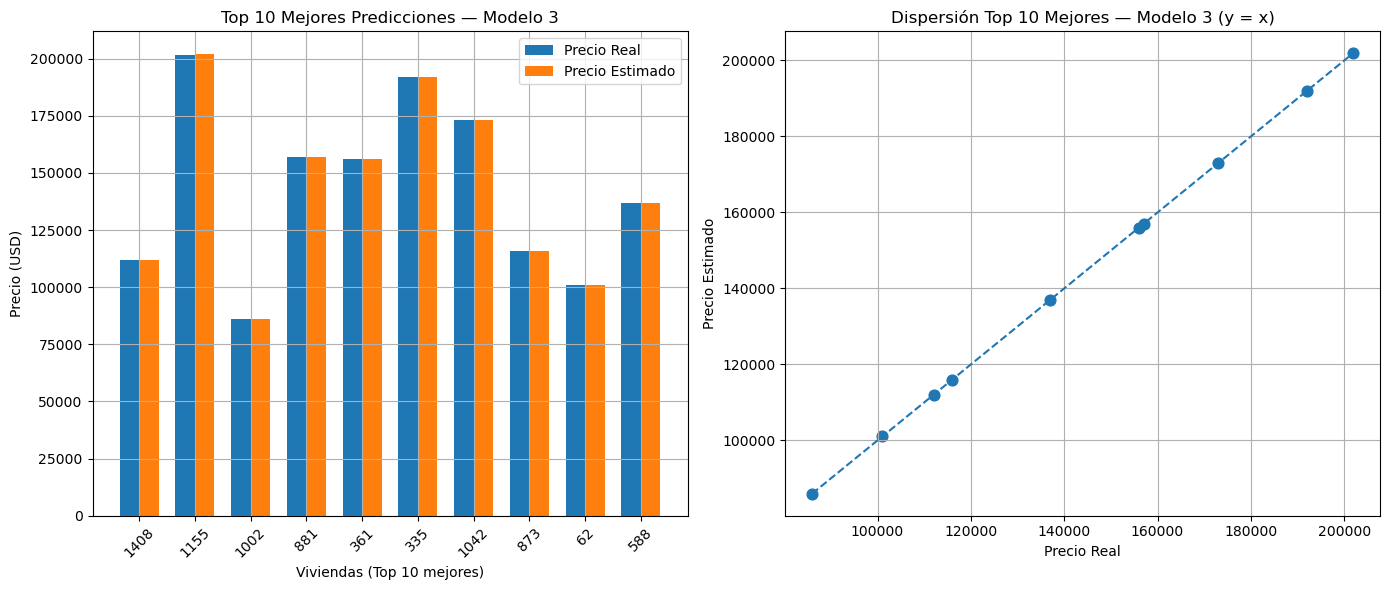

In [39]:
import matplotlib.pyplot as plt
import numpy as np


def graficar_top_mejores_predicciones_modelo_3(top_mejores_m3):
    """
    Genera las gráficas del TOP 10 de mejores predicciones del MODELO 3:
    1) Gráfico de barras: Precio real vs Precio estimado.
    2) Gráfico de dispersión: Precio real vs Precio estimado (y = x).
    """
    ids_mej_m3 = top_mejores_m3["ID"].astype(str)

    plt.figure(figsize=(14, 6))

    # ============================
    # GRÁFICO 1: BARRAS
    # ============================
    plt.subplot(1, 2, 1)

    x = np.arange(len(ids_mej_m3))
    width = 0.35

    plt.bar(x - width / 2, top_mejores_m3["Precio_Real"], width, label="Precio Real")
    plt.bar(x + width / 2, top_mejores_m3["Precio_Estimado"], width, label="Precio Estimado")

    plt.xticks(x, ids_mej_m3, rotation=45)
    plt.xlabel("Viviendas (Top 10 mejores)")
    plt.ylabel("Precio (USD)")
    plt.title("Top 10 Mejores Predicciones — Modelo 3")
    plt.legend()
    plt.grid(True)

    # ============================
    # GRÁFICO 2: DISPERSIÓN
    # ============================
    plt.subplot(1, 2, 2)

    plt.scatter(
        top_mejores_m3["Precio_Real"],
        top_mejores_m3["Precio_Estimado"],
        s=60
    )

    min_val_mej_m3 = min(
        top_mejores_m3["Precio_Real"].min(),
        top_mejores_m3["Precio_Estimado"].min()
    )

    max_val_mej_m3 = max(
        top_mejores_m3["Precio_Real"].max(),
        top_mejores_m3["Precio_Estimado"].max()
    )

    plt.plot([min_val_mej_m3, max_val_mej_m3], [min_val_mej_m3, max_val_mej_m3], '--')

    plt.xlabel("Precio Real")
    plt.ylabel("Precio Estimado")
    plt.title("Dispersión Top 10 Mejores — Modelo 3 (y = x)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# ===============================
# EJECUCIÓN — GRÁFICAS MODELO 3
# ===============================

graficar_top_mejores_predicciones_modelo_3(top_mejores_m3)


In [40]:
import numpy as np


def calcular_rmse_modelo_3(y_m3, y_pred_m3):
    """
    Calcula el MSE y RMSE del MODELO 3
    (Boxplot + Normalización).

    Parámetros:
    y_m3 (Series): Valores reales del precio (dataset limpio).
    y_pred_m3 (ndarray): Valores estimados por el MODELO 3.

    Retorna:
    tuple: (MSE_m3, RMSE_m3)
    """
    residuos_m3 = y_m3.values - y_pred_m3

    MSE_m3 = np.mean(residuos_m3 ** 2)
    RMSE_m3 = np.sqrt(MSE_m3)

    print("\nEVALUACIÓN GLOBAL — MODELO 3")
    print("--------------------------------")
    print(f"MSE:  {MSE_m3:,.2f}")
    print(f"RMSE: {RMSE_m3:,.2f} USD")

    return MSE_m3, RMSE_m3


# ===============================
# EJECUCIÓN — RMSE MODELO 3
# ===============================

MSE_m3, RMSE_m3 = calcular_rmse_modelo_3(y_m3, y_pred_m3)



EVALUACIÓN GLOBAL — MODELO 3
--------------------------------
MSE:  768,913,742.23
RMSE: 27,729.29 USD


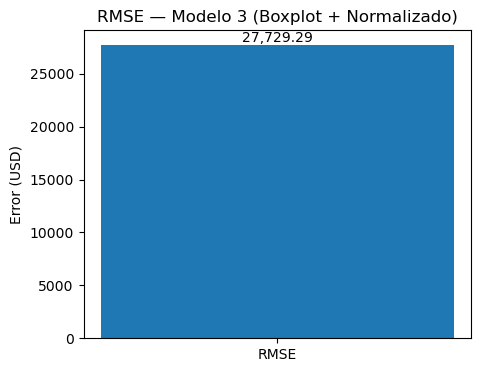

In [41]:
import matplotlib.pyplot as plt


def graficar_rmse_modelo_3(RMSE_m3):
    """
    Grafica el RMSE del MODELO 3 (Boxplot + Normalizado).
    """
    plt.figure(figsize=(5, 4))

    bars_m3 = plt.bar(["RMSE"], [RMSE_m3])

    plt.ylabel("Error (USD)")
    plt.title("RMSE — Modelo 3 (Boxplot + Normalizado)")

    # Mostrar valor encima de la barra
    for bar in bars_m3:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:,.2f}",
            ha="center",
            va="bottom"
        )

    plt.grid(False)
    plt.show()


# ===============================
# EJECUCIÓN — GRÁFICA RMSE MODELO 3
# ===============================

graficar_rmse_modelo_3(RMSE_m3)


In [42]:
import pandas as pd
import numpy as np


def generar_tabla_errores_modelo_3(df_m3, y_m3, y_pred_m3):
    """
    Genera la tabla de errores por vivienda para el MODELO 3
    (Boxplot + Normalizado).

    Parámetros:
    df_m3 (DataFrame): Dataset limpio del modelo 3.
    y_m3 (Series): Precios reales.
    y_pred_m3 (ndarray): Precios estimados por el modelo 3.

    Retorna:
    DataFrame: Tabla de errores por vivienda.
    """
    tabla_errores_m3 = pd.DataFrame({
        "Id": df_m3["Id"],
        "Precio_Real": y_m3.values,
        "Precio_Estimado": y_pred_m3
    })

    tabla_errores_m3["Error"] = (
        tabla_errores_m3["Precio_Real"] -
        tabla_errores_m3["Precio_Estimado"]
    )

    tabla_errores_m3["Error_Absoluto"] = np.abs(
        tabla_errores_m3["Error"]
    )

    tabla_errores_m3["Error_Porcentual (%)"] = (
        tabla_errores_m3["Error_Absoluto"] /
        tabla_errores_m3["Precio_Real"]
    ) * 100

    tabla_original = tabla_errores_m3.head()
    tabla_original = tabla_original.sort_values(
        by="Error_Porcentual (%)",
        ascending=True
    )

    print("\nTABLA DE ERRORES POR VIVIENDA — MODELO 3")
    print("----------------------------------------")
    display(tabla_original)

    return tabla_errores_m3


# ===============================
# EJECUCIÓN — TABLA DE ERRORES MODELO 3
# ===============================

tabla_errores_m3 = generar_tabla_errores_modelo_3(
    df_m3, y_m3, y_pred_m3
)


TABLA DE ERRORES POR VIVIENDA — MODELO 3
----------------------------------------


,Id,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
0,1,208500,212673.706201,-4173.706201,4173.706201,2.001778
1,2,181500,176288.544402,5211.455598,5211.455598,2.871325
2,3,223500,215269.307440,8230.692560,8230.692560,3.682636
4,5,250000,265472.798890,-15472.798890,15472.798890,6.189120
3,4,140000,186495.230712,-46495.230712,46495.230712,33.210879


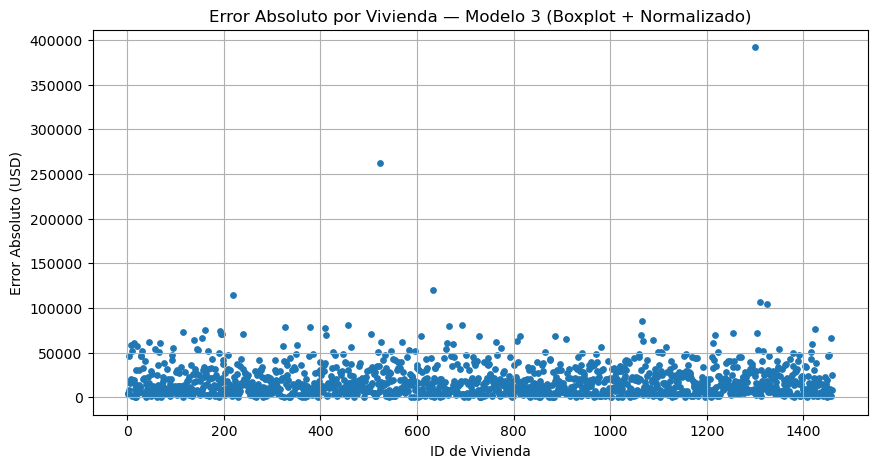

In [43]:
import matplotlib.pyplot as plt


def graficar_error_absoluto_por_vivienda_modelo_3(tabla_errores_m3):
    """
    Grafica el error absoluto por vivienda para el MODELO 3
    (Boxplot + Normalizado).
    """
    plt.figure(figsize=(10, 5))

    plt.scatter(
        tabla_errores_m3["Id"],
        tabla_errores_m3["Error_Absoluto"],
        s=15
    )

    plt.xlabel("ID de Vivienda")
    plt.ylabel("Error Absoluto (USD)")
    plt.title("Error Absoluto por Vivienda — Modelo 3 (Boxplot + Normalizado)")
    plt.grid(True)
    plt.show()


# ===============================
# EJECUCIÓN — GRÁFICA ERROR MODELO 3
# ===============================

graficar_error_absoluto_por_vivienda_modelo_3(tabla_errores_m3)


**COMPARACION FINAL DEFINITIVAD**

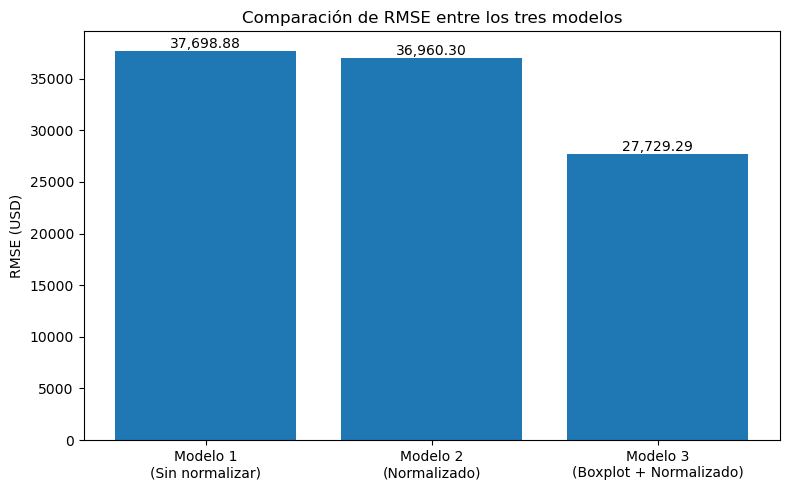

In [44]:
import matplotlib.pyplot as plt


def graficar_comparacion_rmse(RMSE, RMSE_norm, RMSE_m3):
    """
    Grafica la comparación del RMSE entre los tres modelos:
    Modelo 1 (sin normalizar),
    Modelo 2 (normalizado),
    Modelo 3 (boxplot + normalizado).
    """
    modelos = [
        "Modelo 1\n(Sin normalizar)",
        "Modelo 2\n(Normalizado)",
        "Modelo 3\n(Boxplot + Normalizado)"
    ]

    valores_rmse = [RMSE, RMSE_norm, RMSE_m3]

    plt.figure(figsize=(8, 5))

    bars = plt.bar(modelos, valores_rmse)

    plt.ylabel("RMSE (USD)")
    plt.title("Comparación de RMSE entre los tres modelos")

    # Mostrar valores arriba de cada barra
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:,.2f}",
            ha="center",
            va="bottom"
        )

    plt.grid(False)
    plt.tight_layout()
    plt.show()


# ===============================
# EJECUCIÓN — COMPARACIÓN FINAL
# ===============================

graficar_comparacion_rmse(RMSE, RMSE_norm, RMSE_m3)


**TRAIN/TEST**

In [45]:
import numpy as np


def dividir_train_test_modelo_3(df_m3, test_size=0.3, random_seed=42):
    """
    Divide el dataset del MODELO 3 en conjuntos de entrenamiento y prueba
    usando una proporción fija y semilla reproducible.

    Parámetros:
    df_m3 (DataFrame): Dataset limpio del modelo 3.
    test_size (float): Proporción para test (por defecto 30%).
    random_seed (int): Semilla para reproducibilidad.

    Retorna:
    tuple: (df_train_m3, df_test_m3)
    """
    # Semilla para reproducibilidad
    np.random.seed(random_seed)

    # Mezclar índices
    indices = np.random.permutation(len(df_m3))

    # Tamaño train
    tam_train = int((1 - test_size) * len(df_m3))

    # Índices train y test
    train_idx = indices[:tam_train]
    test_idx = indices[tam_train:]

    # Crear datasets
    df_train_m3 = df_m3.iloc[train_idx].copy()
    df_test_m3 = df_m3.iloc[test_idx].copy()

    print("\nDIVISIÓN DE DATOS — MODELO 3")
    print("----------------------------")
    print("Total datos:", len(df_m3))
    print("Train (70%):", len(df_train_m3))
    print("Test (30%): ", len(df_test_m3))

    return df_train_m3, df_test_m3


# ===============================
# EJECUCIÓN — TRAIN / TEST MODELO 3
# ===============================

df_train_m3, df_test_m3 = dividir_train_test_modelo_3(df_m3)



DIVISIÓN DE DATOS — MODELO 3
----------------------------
Total datos: 1399
Train (70%): 979
Test (30%):  420


In [46]:
import numpy as np


def preparar_train_test_modelo_3(df_train_m3, df_test_m3,
                                 columna_objetivo="SalePrice",
                                 columna_id="Id"):
    """
    Separa variables, normaliza usando SOLO el conjunto TRAIN
    y aplica la normalización al conjunto TEST (MODELO 3).
    """
    # ===============================
    # SEPARACIÓN DE VARIABLES
    # ===============================
    # ---------- TRAIN ----------
    X_train_m3 = df_train_m3.drop(columna_objetivo, axis=1)
    y_train_m3 = df_train_m3[columna_objetivo]
    X_train_m3 = X_train_m3.drop(columna_id, axis=1)

    # ---------- TEST ----------
    X_test_m3 = df_test_m3.drop(columna_objetivo, axis=1)
    y_test_m3 = df_test_m3[columna_objetivo]
    X_test_m3 = X_test_m3.drop(columna_id, axis=1)

    print("\nColumnas del modelo (Train/Test)")
    print("--------------------------------")
    print(X_train_m3.columns.tolist())

    # ===============================
    # NORMALIZACIÓN (USANDO SOLO TRAIN)
    # ===============================
    media_train_m3 = X_train_m3.mean()
    std_train_m3 = X_train_m3.std()

    # Normalizar TRAIN
    X_train_norm_m3 = (X_train_m3 - media_train_m3) / std_train_m3

    # Normalizar TEST con parámetros del TRAIN
    X_test_norm_m3 = (X_test_m3 - media_train_m3) / std_train_m3

    print("\nPrimeras filas TRAIN normalizado:")
    display(X_train_norm_m3.head())

    print("\nPrimeras filas TEST normalizado:")
    display(X_test_norm_m3.head())

    return (
        X_train_norm_m3,
        y_train_m3,
        X_test_norm_m3,
        y_test_m3,
        media_train_m3,
        std_train_m3
    )


# ===============================
# EJECUCIÓN — TRAIN / TEST MODELO 3
# ===============================

(
    X_train_norm_m3,
    y_train_m3,
    X_test_norm_m3,
    y_test_m3,
    media_train_m3,
    std_train_m3
) = preparar_train_test_modelo_3(df_train_m3, df_test_m3)



Columnas del modelo (Train/Test)
--------------------------------
['LotArea', 'OverallQual', 'YearBuilt', 'BsmtFinSF1', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'FullBath', 'GarageCars', 'GarageArea']

Primeras filas TRAIN normalizado:


,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea
703,-0.310539,-0.751996,-2.329215,-1.014078,-1.678671,-0.287422,0.763898,0.870643,0.394842,1.055294
656,0.003952,-0.751996,-0.367279,0.967999,0.091883,-0.228026,-0.897475,-1.006801,-0.990643,-0.720815
119,-0.200593,0.023772,1.162366,-1.014078,-0.738463,-1.147257,-0.015349,0.870643,0.394842,-0.335991
502,-0.106788,-0.751996,-0.167760,0.702411,0.503224,0.227347,-0.545062,-1.006801,0.394842,0.014297
243,0.103842,0.023772,0.331037,-1.014078,-0.999064,-1.435754,-0.538496,-1.006801,-0.990643,-0.839222



Primeras filas TEST normalizado:


,LotArea,OverallQual,YearBuilt,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,GarageCars,GarageArea
953,0.145254,-0.751996,-0.034748,0.367966,-0.595388,0.097240,1.105366,0.870643,0.394842,0.354718
1293,0.021548,0.799540,0.198024,-0.537002,-0.472752,-0.853103,0.439942,0.870643,0.394842,0.344850
896,-0.160372,-1.527764,-1.132102,-0.313219,-0.168718,-0.516523,-1.120742,-1.006801,-0.990643,-0.646810
1429,0.339876,0.023772,0.364290,0.653228,1.080633,0.866566,-0.050371,0.870643,0.394842,0.043899
165,0.017050,-0.751996,-0.999089,-0.150915,-0.953076,-0.920985,-0.236428,0.870643,-2.376128,-2.260109


In [47]:
import numpy as np


def entrenar_modelo_3_con_train(X_train_norm_m3, y_train_m3):
    """
    Entrena el MODELO 3 utilizando únicamente el conjunto TRAIN
    mediante el método de mínimos cuadrados (ecuación normal).

    Parámetros:
    X_train_norm_m3 (DataFrame): Variables independientes normalizadas (TRAIN).
    y_train_m3 (Series): Variable objetivo (TRAIN).

    Retorna:
    ndarray: Coeficientes del modelo entrenado.
    """
    # Número de muestras
    n_train_m3 = X_train_norm_m3.shape[0]

    # Columna de unos (intercepto)
    columna_unos_train = np.ones((n_train_m3, 1))

    # Matriz A de entrenamiento
    A_train_m3 = np.hstack((columna_unos_train, X_train_norm_m3.values))

    # Vector b (precios reales)
    b_train_m3 = y_train_m3.values

    print("\nDimensión matriz A_train:")
    print(A_train_m3.shape)

    # ===============================
    # MÍNIMOS CUADRADOS — ECUACIÓN NORMAL
    # ===============================
    AT_train = A_train_m3.T
    ATA_train = np.dot(AT_train, A_train_m3)
    ATb_train = np.dot(AT_train, b_train_m3)

    coeficientes_train_m3 = np.linalg.solve(ATA_train, ATb_train)

    print("\nCoeficientes del MODELO 3 (TRAIN)")
    print("---------------------------------")
    print(coeficientes_train_m3)

    return coeficientes_train_m3


# ===============================
# EJECUCIÓN — ENTRENAMIENTO MODELO 3 (TRAIN)
# ===============================

coeficientes_train_m3 = entrenar_modelo_3_con_train(
    X_train_norm_m3, y_train_m3
)



Dimensión matriz A_train:
(979, 11)

Coeficientes del MODELO 3 (TRAIN)
---------------------------------
[169330.22165475   5058.13124961  23795.99206051   9839.69056696
   5904.19105439   6121.08325732   -598.36120196  18313.41451374
   -721.80451178    968.04489408   6611.31693392]


In [48]:
import numpy as np


def predecir_test_modelo_3(X_test_norm_m3, y_test_m3, coeficientes_train_m3):
    """
    Realiza la predicción del MODELO 3 sobre el conjunto TEST
    usando los coeficientes entrenados con TRAIN.

    Parámetros:
    X_test_norm_m3 (DataFrame): Variables independientes normalizadas (TEST).
    y_test_m3 (Series): Valores reales del precio (TEST).
    coeficientes_train_m3 (ndarray): Coeficientes obtenidos con TRAIN.

    Retorna:
    ndarray: Predicciones sobre el conjunto TEST.
    """
    # Número de muestras test
    n_test_m3 = X_test_norm_m3.shape[0]

    # Columna de unos (intercepto)
    columna_unos_test = np.ones((n_test_m3, 1))

    # Matriz A del TEST
    A_test_m3 = np.hstack((columna_unos_test, X_test_norm_m3.values))

    # Predicción
    y_pred_test_m3 = np.dot(A_test_m3, coeficientes_train_m3)

    print("\nPrimeras 5 predicciones TEST:")
    print(y_pred_test_m3[:5])

    print("\nPrimeros 5 valores reales TEST:")
    print(y_test_m3.values[:5])

    return y_pred_test_m3


# ===============================
# EJECUCIÓN — PREDICCIÓN TEST MODELO 3
# ===============================

y_pred_test_m3 = predecir_test_modelo_3(
    X_test_norm_m3, y_test_m3, coeficientes_train_m3
)



Primeras 5 predicciones TEST:
[172640.44871896 194950.25408967  93418.71690057 184273.99774845
 113316.7146671 ]

Primeros 5 valores reales TEST:
[172000 162900 106500 182900 127500]


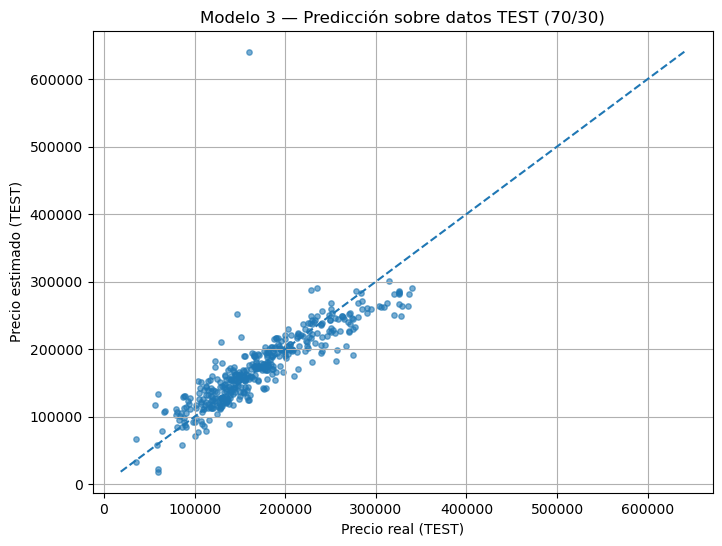

In [49]:
import matplotlib.pyplot as plt


def graficar_prediccion_test_modelo_3(y_test_m3, y_pred_test_m3):
    """
    Grafica la comparación entre precios reales y precios estimados
    sobre el conjunto TEST del MODELO 3 (70/30).
    """
    plt.figure(figsize=(8, 6))

    plt.scatter(y_test_m3, y_pred_test_m3, alpha=0.6, s=15)

    # Línea ideal y = x
    min_val_test = min(y_test_m3.min(), y_pred_test_m3.min())
    max_val_test = max(y_test_m3.max(), y_pred_test_m3.max())

    plt.plot([min_val_test, max_val_test],
             [min_val_test, max_val_test], '--')

    plt.xlabel("Precio real (TEST)")
    plt.ylabel("Precio estimado (TEST)")
    plt.title("Modelo 3 — Predicción sobre datos TEST (70/30)")
    plt.grid(True)
    plt.show()


# ===============================
# EJECUCIÓN — GRÁFICA TEST MODELO 3
# ===============================

graficar_prediccion_test_modelo_3(y_test_m3, y_pred_test_m3)


In [50]:
import numpy as np


def calcular_rmse_test_modelo_3(y_test_m3, y_pred_test_m3):
    """
    Calcula el MSE y RMSE del MODELO 3 sobre el conjunto TEST (70/30).

    Parámetros:
    y_test_m3 (Series): Valores reales del precio (TEST).
    y_pred_test_m3 (ndarray): Valores estimados por el modelo (TEST).

    Retorna:
    tuple: (MSE_test_m3, RMSE_test_m3)
    """
    residuos_test_m3 = y_test_m3.values - y_pred_test_m3

    MSE_test_m3 = np.mean(residuos_test_m3 ** 2)
    RMSE_test_m3 = np.sqrt(MSE_test_m3)

    print("\nEVALUACIÓN MODELO 3 — TEST (70/30)")
    print("----------------------------------")
    print(f"MSE TEST:  {MSE_test_m3:,.2f}")
    print(f"RMSE TEST: {RMSE_test_m3:,.2f} USD")

    return MSE_test_m3, RMSE_test_m3


# ===============================
# EJECUCIÓN — RMSE TEST MODELO 3
# ===============================

MSE_test_m3, RMSE_test_m3 = calcular_rmse_test_modelo_3(
    y_test_m3, y_pred_test_m3
)


EVALUACIÓN MODELO 3 — TEST (70/30)
----------------------------------
MSE TEST:  1,154,097,580.01
RMSE TEST: 33,972.01 USD


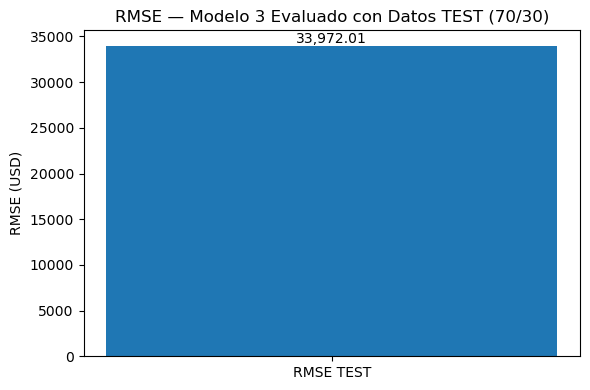

In [51]:
import matplotlib.pyplot as plt


def graficar_rmse_test_modelo_3(RMSE_test_m3):
    """
    Grafica el RMSE del MODELO 3 evaluado sobre el conjunto TEST (70/30).
    """
    plt.figure(figsize=(6, 4))

    plt.bar(["RMSE TEST"], [RMSE_test_m3])

    # Mostrar valor arriba de la barra
    plt.text(
        0,
        RMSE_test_m3,
        f"{RMSE_test_m3:,.2f}",
        ha="center",
        va="bottom"
    )

    plt.ylabel("RMSE (USD)")
    plt.title("RMSE — Modelo 3 Evaluado con Datos TEST (70/30)")
    plt.grid(False)
    plt.tight_layout()
    plt.show()


# ===============================
# EJECUCIÓN — GRÁFICA RMSE TEST
# ===============================

graficar_rmse_test_modelo_3(RMSE_test_m3)


In [52]:
import pandas as pd
import numpy as np


def generar_tabla_errores_test_modelo_3(df_test_m3, y_test_m3, y_pred_test_m3):
    """
    Genera la tabla de errores por vivienda para el MODELO 3
    evaluado sobre el conjunto TEST (70/30).

    Parámetros:
    df_test_m3 (DataFrame): Dataset de prueba del modelo 3.
    y_test_m3 (Series): Precios reales (TEST).
    y_pred_test_m3 (ndarray): Precios estimados por el modelo (TEST).

    Retorna:
    DataFrame: Tabla de errores por vivienda (TEST).
    """
    precio_real_test_m3 = y_test_m3.values
    precio_estimado_test_m3 = y_pred_test_m3

    error_test_m3 = precio_real_test_m3 - precio_estimado_test_m3
    error_abs_test_m3 = np.abs(error_test_m3)
    error_pct_test_m3 = (error_abs_test_m3 / precio_real_test_m3) * 100

    tabla_errores_test_m3 = pd.DataFrame({
        "Id": df_test_m3["Id"].values,
        "Precio_Real": precio_real_test_m3,
        "Precio_Estimado": precio_estimado_test_m3,
        "Error": error_test_m3,
        "Error_Absoluto": error_abs_test_m3,
        "Error_Porcentual (%)": error_pct_test_m3
    })

    tabla_original = tabla_errores_test_m3.head()
    tabla_original = tabla_original.sort_values(
        by="Error_Porcentual (%)",
        ascending=True
    )

    print("\nTABLA DE ERRORES POR VIVIENDA — MODELO 3 (TEST)")
    print("------------------------------------------------")
    display(tabla_original)

    return tabla_errores_test_m3


# ===============================
# EJECUCIÓN — TABLA ERRORES TEST
# ===============================

tabla_errores_test_m3 = generar_tabla_errores_test_modelo_3(
    df_test_m3, y_test_m3, y_pred_test_m3
)



TABLA DE ERRORES POR VIVIENDA — MODELO 3 (TEST)
------------------------------------------------


,Id,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
0,954,172000,172640.448719,-640.448719,640.448719,0.372354
3,1430,182900,184273.997748,-1373.997748,1373.997748,0.751229
4,166,127500,113316.714667,14183.285333,14183.285333,11.124145
2,897,106500,93418.716901,13081.283099,13081.283099,12.282895
1,1294,162900,194950.254090,-32050.254090,32050.254090,19.674803


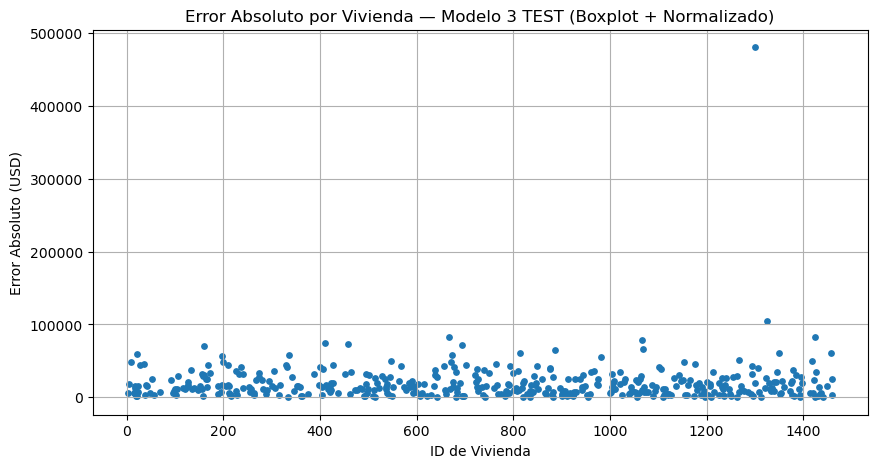

In [53]:
import matplotlib.pyplot as plt


def graficar_error_absoluto_por_vivienda_modelo_3_test(tabla_errores_test_m3):
    """
    Grafica el error absoluto por vivienda para el MODELO 3
    (Boxplot + Normalizado) — TEST.
    """
    plt.figure(figsize=(10, 5))

    plt.scatter(
        tabla_errores_test_m3["Id"],
        tabla_errores_test_m3["Error_Absoluto"],
        s=15
    )

    plt.xlabel("ID de Vivienda")
    plt.ylabel("Error Absoluto (USD)")
    plt.title("Error Absoluto por Vivienda — Modelo 3 TEST (Boxplot + Normalizado)")
    plt.grid(True)
    plt.show()


# ===============================
# EJECUCIÓN — GRÁFICA ERROR MODELO 3 TEST
# ===============================

graficar_error_absoluto_por_vivienda_modelo_3_test(tabla_errores_test_m3)


In [54]:
import pandas as pd


def obtener_top_peores_predicciones_test_modelo_3(tabla_errores_test_m3, top_n=10):
    """
    Genera la tabla del TOP 10 de peores predicciones del MODELO 3
    evaluado sobre el conjunto TEST (70/30).

    Parámetros:
    tabla_errores_test_m3 (DataFrame): Tabla de errores del MODELO 3 (TEST).
    top_n (int): Número de registros a mostrar.

    Retorna:
    DataFrame: TOP peores predicciones (TEST).
    """
    top_peores_test_m3 = tabla_errores_test_m3.sort_values(
        by="Error_Absoluto",
        ascending=False
    ).head(top_n)

    top_peores_test_m3 = top_peores_test_m3.sort_values(
        by="Error_Porcentual (%)",
        ascending=True
    )

    print("\nTOP 10 PEORES PREDICCIONES — MODELO 3 (TEST)")
    print("--------------------------------------------")
    display(top_peores_test_m3)

    return top_peores_test_m3


# ===============================
# EJECUCIÓN — TOP PEORES TEST
# ===============================

top_peores_test_m3 = obtener_top_peores_predicciones_test_modelo_3(
    tabla_errores_test_m3
)



TOP 10 PEORES PREDICCIONES — MODELO 3 (TEST)
--------------------------------------------


,Id,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
71,693,335000,263891.003639,71108.996361,71108.996361,21.226566
118,160,320000,249996.594385,70003.405615,70003.405615,21.876064
342,1066,328000,249363.447205,78636.552795,78636.552795,23.974559
157,458,256000,182853.891776,73146.108224,73146.108224,28.572699
382,1424,274970,191818.637449,83151.362551,83151.362551,30.240158
149,1069,151400,217574.264978,-66174.264978,66174.264978,43.708233
264,667,129000,211154.608110,-82154.608110,82154.608110,63.685743
380,1325,147000,252300.285341,-105300.285341,105300.285341,71.632847
320,411,60000,133789.498466,-73789.498466,73789.498466,122.982497
296,1299,160000,640401.621546,-480401.621546,480401.621546,300.251013


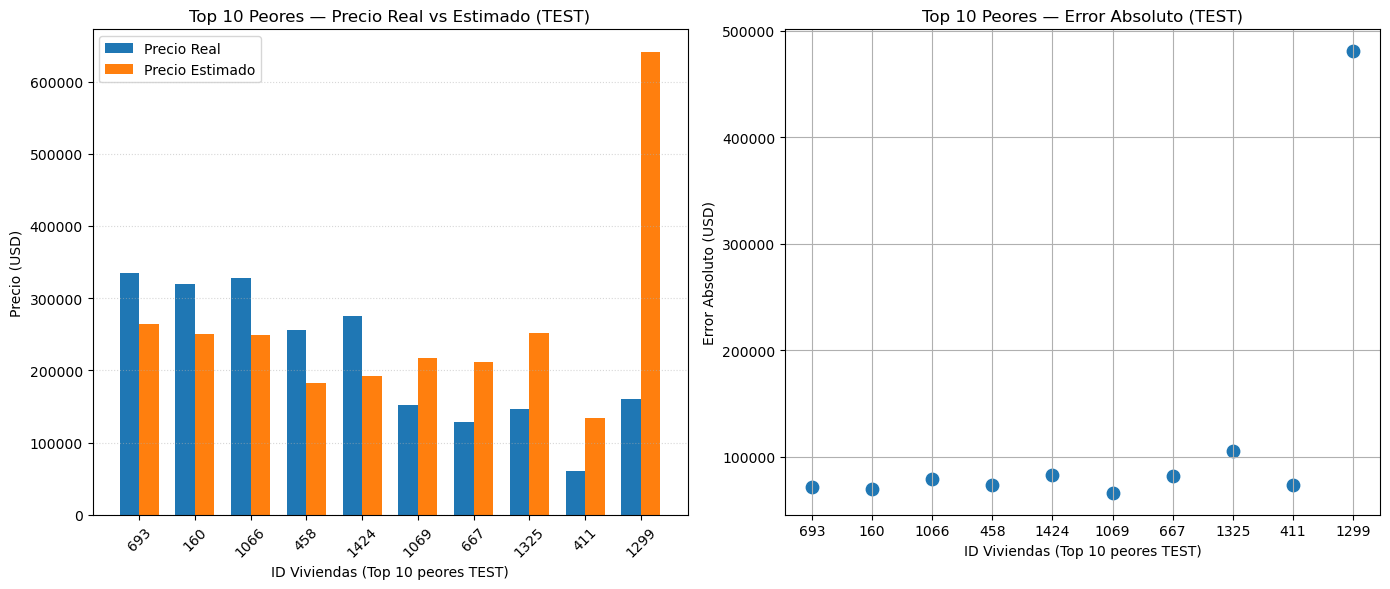

In [55]:
import matplotlib.pyplot as plt
import numpy as np


def graficar_top_peores_test_modelo_3(top_peores_test_m3):
    """
    Genera las gráficas del TOP 10 de peores predicciones del MODELO 3
    evaluado sobre el conjunto TEST:
    1) Barras: Precio real vs Precio estimado
    2) Dispersión: Error absoluto
    """
    ids = top_peores_test_m3["Id"].astype(str)

    precio_real = top_peores_test_m3["Precio_Real"]
    precio_estimado = top_peores_test_m3["Precio_Estimado"]
    error_abs = top_peores_test_m3["Error_Absoluto"]

    x = np.arange(len(ids))
    ancho = 0.35

    plt.figure(figsize=(14, 6))

    # ============================
    # GRÁFICO 1 — BARRAS (PRECIOS)
    # ============================
    plt.subplot(1, 2, 1)

    plt.bar(x - ancho / 2, precio_real, ancho, label="Precio Real")
    plt.bar(x + ancho / 2, precio_estimado, ancho, label="Precio Estimado")

    plt.xticks(x, ids, rotation=45)
    plt.xlabel("ID Viviendas (Top 10 peores TEST)")
    plt.ylabel("Precio (USD)")
    plt.title("Top 10 Peores — Precio Real vs Estimado (TEST)")
    plt.legend()
    plt.grid(axis="y", linestyle=":", alpha=0.5)

    # ============================
    # GRÁFICO 2 — ERROR ABSOLUTO
    # ============================
    plt.subplot(1, 2, 2)

    plt.scatter(ids, error_abs, s=80)

    plt.xlabel("ID Viviendas (Top 10 peores TEST)")
    plt.ylabel("Error Absoluto (USD)")
    plt.title("Top 10 Peores — Error Absoluto (TEST)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# ===============================
# EJECUCIÓN — GRÁFICAS TOP PEORES TEST
# ===============================

graficar_top_peores_test_modelo_3(top_peores_test_m3)


In [56]:
import pandas as pd


def obtener_top_mejores_predicciones_test_modelo_3(tabla_errores_test_m3, top_n=10):
    """
    Genera la tabla del TOP 10 de mejores predicciones del MODELO 3
    evaluado sobre el conjunto TEST (70/30).

    Parámetros:
    tabla_errores_test_m3 (DataFrame): Tabla de errores del MODELO 3 (TEST).
    top_n (int): Número de registros a mostrar.

    Retorna:
    DataFrame: TOP mejores predicciones (TEST).
    """
    top_mejores_test_m3 = tabla_errores_test_m3.sort_values(
        by="Error_Absoluto",
        ascending=True
    ).head(top_n)

    top_mejores_test_m3 = top_mejores_test_m3.sort_values(
        by="Error_Porcentual (%)",
        ascending=True
    )

    print("\nTOP 10 MEJORES PREDICCIONES — MODELO 3 (TEST)")
    print("---------------------------------------------")
    display(top_mejores_test_m3)

    return top_mejores_test_m3


# ===============================
# EJECUCIÓN — TOP MEJORES TEST
# ===============================

top_mejores_test_m3 = obtener_top_mejores_predicciones_test_modelo_3(
    tabla_errores_test_m3
)



TOP 10 MEJORES PREDICCIONES — MODELO 3 (TEST)
---------------------------------------------


,Id,Precio_Real,Precio_Estimado,Error,Error_Absoluto,Error_Porcentual (%)
268,681,143000,143054.969871,-54.969871,54.969871,0.038440
363,1440,197000,196883.697397,116.302603,116.302603,0.059037
361,819,155000,154832.433707,167.566293,167.566293,0.108107
187,1197,219210,218848.248349,361.751651,361.751651,0.165025
353,742,142000,141745.344576,254.655424,254.655424,0.179335
62,835,139950,139607.545872,342.454128,342.454128,0.244697
378,1208,200000,200560.731712,-560.731712,560.731712,0.280366
0,954,172000,172640.448719,-640.448719,640.448719,0.372354
276,1109,181000,180300.719672,699.280328,699.280328,0.386343
265,1425,144000,143419.895226,580.104774,580.104774,0.402851


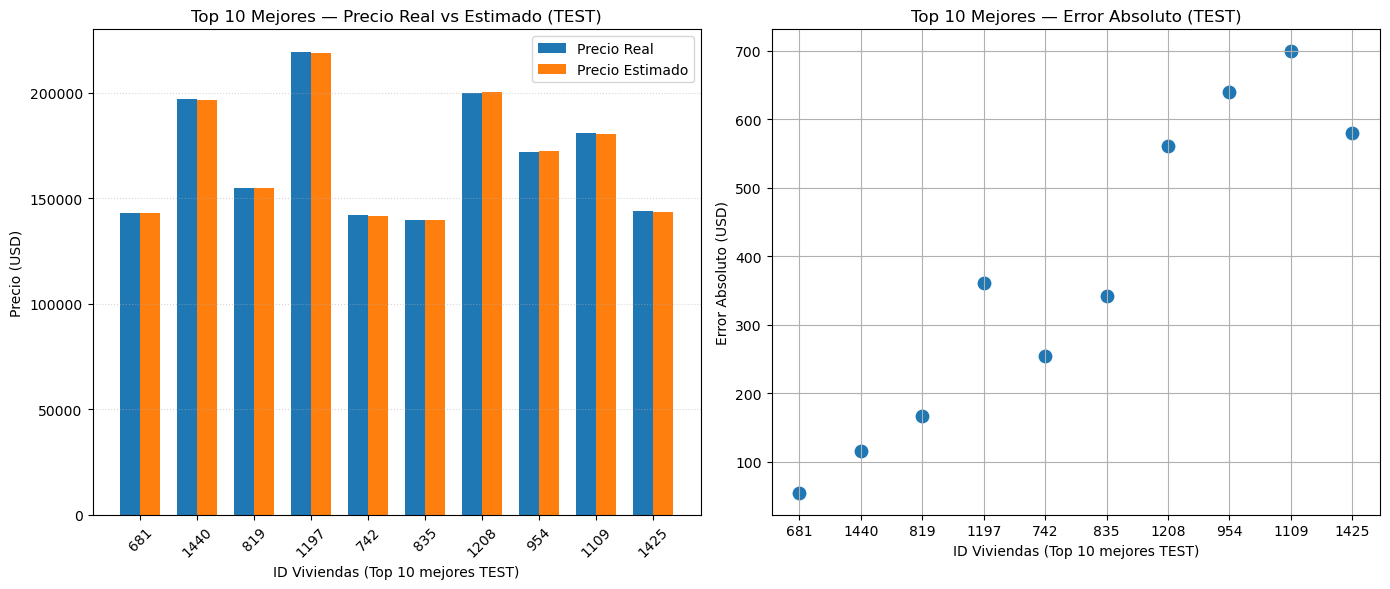

In [57]:
import matplotlib.pyplot as plt
import numpy as np


def graficar_top_mejores_test_modelo_3(top_mejores_test_m3):
    """
    Genera las gráficas del TOP 10 de mejores predicciones del MODELO 3
    evaluado sobre el conjunto TEST:
    1) Barras: Precio real vs Precio estimado
    2) Dispersión: Error absoluto
    """
    ids = top_mejores_test_m3["Id"].astype(str)

    precio_real = top_mejores_test_m3["Precio_Real"]
    precio_estimado = top_mejores_test_m3["Precio_Estimado"]
    error_abs = top_mejores_test_m3["Error_Absoluto"]

    x = np.arange(len(ids))
    ancho = 0.35

    plt.figure(figsize=(14, 6))

    # ============================
    # GRÁFICO 1 — BARRAS (PRECIOS)
    # ============================
    plt.subplot(1, 2, 1)

    plt.bar(x - ancho / 2, precio_real, ancho, label="Precio Real")
    plt.bar(x + ancho / 2, precio_estimado, ancho, label="Precio Estimado")

    plt.xticks(x, ids, rotation=45)
    plt.xlabel("ID Viviendas (Top 10 mejores TEST)")
    plt.ylabel("Precio (USD)")
    plt.title("Top 10 Mejores — Precio Real vs Estimado (TEST)")
    plt.legend()
    plt.grid(axis="y", linestyle=":", alpha=0.5)

    # ============================
    # GRÁFICO 2 — ERROR ABSOLUTO
    # ============================
    plt.subplot(1, 2, 2)

    plt.scatter(ids, error_abs, s=80)

    plt.xlabel("ID Viviendas (Top 10 mejores TEST)")
    plt.ylabel("Error Absoluto (USD)")
    plt.title("Top 10 Mejores — Error Absoluto (TEST)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# ===============================
# EJECUCIÓN — GRÁFICAS TOP MEJORES TEST
# ===============================

graficar_top_mejores_test_modelo_3(top_mejores_test_m3)


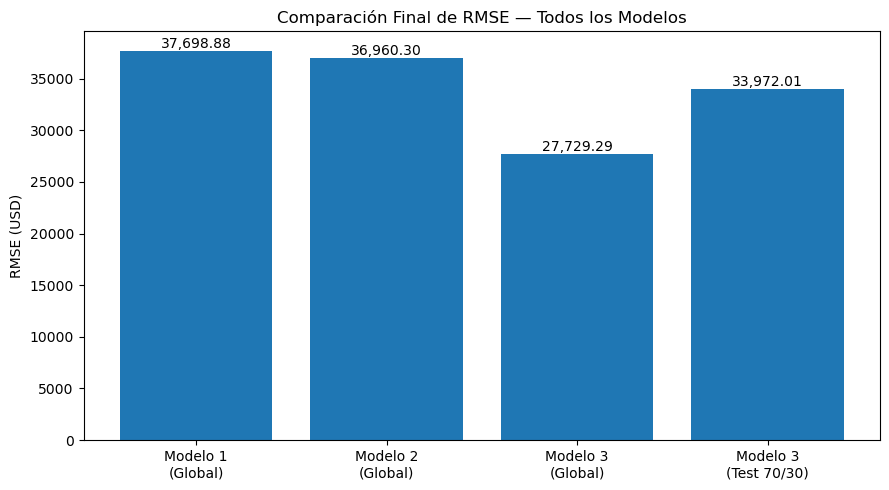

In [58]:
import matplotlib.pyplot as plt


def graficar_comparacion_rmse_completa(
    RMSE,
    RMSE_norm,
    RMSE_m3,
    RMSE_test_m3
):
    """
    Grafica la comparación completa de RMSE:
    - Modelo 1 (sin normalizar)
    - Modelo 2 (normalizado)
    - Modelo 3 global
    - Modelo 3 evaluado en TEST
    """
    etiquetas = [
        "Modelo 1\n(Global)",
        "Modelo 2\n(Global)",
        "Modelo 3\n(Global)",
        "Modelo 3\n(Test 70/30)"
    ]

    valores = [
        RMSE,
        RMSE_norm,
        RMSE_m3,
        RMSE_test_m3
    ]

    plt.figure(figsize=(9, 5))

    barras = plt.bar(etiquetas, valores)

    plt.ylabel("RMSE (USD)")
    plt.title("Comparación Final de RMSE — Todos los Modelos")

    # Mostrar valores encima de cada barra
    for barra in barras:
        altura = barra.get_height()
        plt.text(
            barra.get_x() + barra.get_width() / 2,
            altura,
            f"{altura:,.2f}",
            ha="center",
            va="bottom"
        )

    plt.grid(False)
    plt.tight_layout()
    plt.show()


# ===============================
# EJECUCIÓN — COMPARACIÓN FINAL
# ===============================

graficar_comparacion_rmse_completa(
    RMSE,
    RMSE_norm,
    RMSE_m3,
    RMSE_test_m3
)
